In [11]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import shap

import joblib


valeurs_manquantes_connues = ["N/A", "n/a", "NA", "?", "inconnu", "Inconnu", "", " ", "nan", "NaN", "null", "None", "-"]
data = pd.read_csv("churn_data.csv", na_values=valeurs_manquantes_connues)
da=data.copy()
display(da)

RANDOM_STATE = 42


,customer_id,age,genre,anciennete_mois,type_contrat,charges_mensuelles,charges_totales,methode_paiement,date_derniere_activite,score_engagement,nb_reclamations,churn
0,CUST-01072,22.0,homme,14.0,Mensuel,33.23,488.52,Carte bancaire,"May 11, 2022",79.3,0.0,0
1,CUST-01201,23.0,Homme,33.0,Mensuel,42.67,1432.1,Virement,2023-09-15,NaN,2.0,0
2,CUST-02719,36.0,Homme,70.0,Mensuel,53.44,"3752,45",Prelevement,09-05-23,55.5,1.0,0
3,CUST-01290,38.0,H,28.0,Mensuel,58.49,1647.42€,Carte bancaire,29/09/2023,58.1,1.0,1
4,CUST-03688,32.0,Femme,70.0,Mensuel,35.20,2459.46,Carte bancaire,"August 26, 2023",34.3,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4010,CUST-01131,52.0,Femme,52.0,Mensuel,72.94,3720.44,Virement,02-04-22,45.9,1.0,0
4011,CUST-01295,37.0,femme,66.0,Deux ans,62.70,"4082,84",Carte bancaire,25-05-22,40.5,1.0,0
4012,CUST-00861,18.0,NaN,24.0,Mensuel,65.65,1542.11,Prelevement,2022-08-31,60.4,0.0,1
4013,CUST-03508,38.0,Male,17.0,Mensuel,54.77,898.21,Cheque,"September 12, 2022",72.1,0.0,1


In [12]:
display(HTML("<h1 style='font-size:36px;text-align:center;'>COMPREHENSION METIERS-DICTIONNAIRE DE DONNEES.\n</h1>"))


print("\033[91mBUT DU PROJET:\033[0m\nLe but de ce projet est de prédire, à partir des caractéristiques et du comportement d'un client, s'il va résilier son abonnement (churn) ou rester fidèle, afin de permettre à l'entreprise d'agir en amont pour retenir les clients à risque.")

print("\033[92m1-Que represente chaque ligne? \033[0m\nChaque ligne represente un client unique,avec toutes ses caracteristiques et,l'information si oui ou non il a fini par realiser son abonnement(churn).")

print("\033[92m2-Dictionnaire des colonnes du dataset churn \033[0m\n")

da_dictionnaire={
    
    "customer_id": "l'identifiant unique du client",
    "age": "L'age du client",
    "genre":" Le genre du client",
    "anciennete_mois":"Depuis combien de mois il est abonné",
    "type_contrat" :" le type d'engagement qu'il a signé (mensuel, annuel, deux ans)",
    "charges_mensuelles":"combien il paie par mois pour son abonnement",
    "charges_totales" :"combien il paie au total depuis le début de son abonnement",
    "methode_paiement" : "comment il paie",
    "date_derniere_activite" : "la dernière fois qu'il a utilisé le service",
    "score_engagement": "un indicateur (fictif) de son niveau d'interaction avec le service",
    "nb_reclamations" : "combien de fois il a contacté le service client pour se plaindre",
    "churn (la cible)" : "1 s'il a fini par résilier / partir, 0 s'il est resté client",
    
}

pd.set_option("display.max_colwidth", None) 
df_dico =pd.DataFrame(da_dictionnaire.items(),
             columns=["colonnne","Description"])
display(df_dico)

BUT DU PROJET:
Le but de ce projet est de prédire, à partir des caractéristiques et du comportement d'un client, s'il va résilier son abonnement (churn) ou rester fidèle, afin de permettre à l'entreprise d'agir en amont pour retenir les clients à risque.
1-Que represente chaque ligne? 
Chaque ligne represente un client unique,avec toutes ses caracteristiques et,l'information si oui ou non il a fini par realiser son abonnement(churn).
2-Dictionnaire des colonnes du dataset churn 



,colonnne,Description
0,customer_id,l'identifiant unique du client
1,age,L'age du client
2,genre,Le genre du client
3,anciennete_mois,Depuis combien de mois il est abonné
4,type_contrat,"le type d'engagement qu'il a signé (mensuel, annuel, deux ans)"
5,charges_mensuelles,combien il paie par mois pour son abonnement
6,charges_totales,combien il paie au total depuis le début de son abonnement
7,methode_paiement,comment il paie
8,date_derniere_activite,la dernière fois qu'il a utilisé le service
9,score_engagement,un indicateur (fictif) de son niveau d'interaction avec le service


In [13]:
display(HTML("<h1 style='font-size:36px;text-align:center;'>PREMIER CONTACT AVEC LE DATASET</h1>"))


#dimension du dataset
display(HTML("<h1 style='font-size:20px;color:blue;'>dimension du dataset</h1>"))
print(f"La dimension du dataset:{da.shape}")
print(f"Nombre de ligne: {da.shape[0]}")
print(f"nNombre de colonne: {da.shape[1]}")



# verification de doublons
display(HTML("<h1 style='font-size:20px;color:blue;'> Detection de boublons</h1>"))
print(f"le nombres de dounlons:{da.duplicated().sum()}")
print("\033[94m DECISION: suprimer les 15 doublons.\033[0m \n")
#Supression de doublons
display(HTML("<h1 style='font-size:20px;color:green;'>Supression de doublons</h1>"))
da=da.drop_duplicates()
print(f"le nombres de dounlons:{da.duplicated().sum()}")
print("\033[92m RESULAT:pas de doublons\033[0m \n")



#Detection des erreurs de types
display(HTML("<h1 style='font-size:20px;color:blue;'>Detection des erreurs de types</h1>"))
type_types=pd.DataFrame(da.dtypes,columns=["Types des colonnes"])
display(type_types)
print("\033[91m ANAlYSE:  5erreurs de type--- age et anciennete_mois en float,date_derniere_activite est en object au lieu d'un format datetime, nb_reclamations est en object au lieu d'un type numérique,\ncharges_totales est en object au lieu d'etre en float\033[0m \n ")
print("\033[94m DECISION:Convertir date_derniere_activite en datetime,convertir nb_reclamations en numerique,convertir en float charges_totales.\033[0m \n")
#Gestion des erreurs de types
display(HTML("<h1 style='font-size:20px;color:green;'>Gestion des erreurs de types</h1>"))
da["date_derniere_activite"]=pd.to_datetime(da["date_derniere_activite"],format="mixed",dayfirst=True,errors="coerce")
da["nb_reclamations"]= pd.to_numeric(da["nb_reclamations"],errors="coerce").astype("Int64")
da["age"] = da["age"].astype("Int64")
da["anciennete_mois"] = da["anciennete_mois"].astype("Int64")
da["charges_totales"]= (
    da["charges_totales"]
    .astype(str)
    .str.strip()
    .str.replace("€", "", regex=False)
    .str.replace(",", ".", regex=False)
    .replace("nan", np.nan)  # après astype(str), les NaN deviennent "nan" littéral
    .astype("Float64")
)
print(da.dtypes)
display(da.head(10))
print("\033[92m RESULAT:pas d'erreurs de types\033[0m\n")



# Detection des erreurs structurelles sur les objects et categories
display(HTML("<h1 style='font-size:20px;color:blue;'>Detection des erreurs structurelles</h1>"))
for col in ['genre', 'type_contrat', 'methode_paiement']:
    print(f"\033[1m{col}\033[0m : {da[col].unique().tolist()}")

print("\033[91m ANAlYSE: les variables genre,type_contrat,methode_paiement ont bien des erreurs de structures. \033[0m \n ")
print("\033[94m DÉCISION: harmoniser les catégories de genre, type_contrat et methode_paiement (mise en minuscule, suppression des espaces, regroupement des variantes comme 'H'/'Homme'/'homme'/'Male' en une seule catégorie). \033[0m \n")
# Gestions des erreurs structurelles
display(HTML("<h1 style='font-size:20px;color:blue;'>Gestions des erreurs structurelles</h1>"))
da["genre"] = (
    da["genre"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "h": "homme",
        "male": "homme",
        "m": "homme",
        "female": "femme",
        "f": "femme",
        "nan": np.nan,   # car .astype(str) transforme les vrais NaN en chaîne "nan"
    })
)    
da["type_contrat"] = (
    da["type_contrat"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace("nan", np.nan)
)
da["methode_paiement"] = (
    da["methode_paiement"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace("nan", np.nan)
)
for col in ['genre', 'type_contrat', 'methode_paiement']:
    print(f"\033[1m{col}\033[0m : {da[col].unique().tolist()}")


# creation de features (date) 
display(HTML("<h1 style='font-size:20px;color:blue;'>Creations de features</h1>"))
display(HTML("<h1 style='font-size:20px;color:green;'>date</h1>"))
da["jours_depuis_activite"] = (pd.Timestamp("2024-01-01") - da["date_derniere_activite"]).dt.days.astype("Int64")  
display(da[["date_derniere_activite","jours_depuis_activite"]])
display(da)

print("\033[94m Suite au premier contact avec le dataset , nous avons détecté des erreurs structurelles "
      "des erreurs de types.\n Leur traitement ne sera pas géré par le modèle, "
      "mais en amont par le créateur de l'application, qui devra mettre en place des conditions\n "
      "de validation afin d'éviter les erreurs structurelles et les mauvais types de données à l'entrée. "
      "Tout sera nettoyé et structuré avant que les données n'atteignent le modèle. \033[0m")

La dimension du dataset:(4015, 12)
Nombre de ligne: 4015
nNombre de colonne: 12


le nombres de dounlons:15
 DECISION: suprimer les 15 doublons. 



le nombres de dounlons:0
 RESULAT:pas de doublons 



,Types des colonnes
customer_id,object
age,float64
genre,object
anciennete_mois,float64
type_contrat,object
charges_mensuelles,float64
charges_totales,object
methode_paiement,object
date_derniere_activite,object
score_engagement,float64


 ANAlYSE:  5erreurs de type--- age et anciennete_mois en float,date_derniere_activite est en object au lieu d'un format datetime, nb_reclamations est en object au lieu d'un type numérique,
charges_totales est en object au lieu d'etre en float 
 
 DECISION:Convertir date_derniere_activite en datetime,convertir nb_reclamations en numerique,convertir en float charges_totales. 



...

genre : ['homme', 'Homme', ' Homme ', 'H', 'Femme', 'femme', 'Female', 'M', 'F', 'Male', nan]
type_contrat : ['Mensuel', 'Annuel', 'Deux ans', nan, 'ANNUEL', 'mensuel ']
methode_paiement : ['Carte bancaire', 'Virement', 'Prelevement', 'Cheque', nan]
 ANAlYSE: les variables genre,type_contrat,methode_paiement ont bien des erreurs de structures.  
 
 DÉCISION: harmoniser les catégories de genre, type_contrat et methode_paiement (mise en minuscule, suppression des espaces, regroupement des variantes comme 'H'/'Homme'/'homme'/'Male' en une seule catégorie).  



genre : ['homme', 'femme', nan]
type_contrat : ['mensuel', 'annuel', 'deux ans', nan]
methode_paiement : ['carte bancaire', 'virement', 'prelevement', 'cheque', nan]


,date_derniere_activite,jours_depuis_activite
0,2022-05-11,600
1,2023-09-15,108
2,2023-05-09,237
3,2023-09-29,94
4,2023-08-26,128
...,...,...
4010,2022-04-02,639
4011,2022-05-25,586
4012,2022-08-31,488
4013,2022-09-12,476


,customer_id,age,genre,anciennete_mois,type_contrat,charges_mensuelles,charges_totales,methode_paiement,date_derniere_activite,score_engagement,nb_reclamations,churn,jours_depuis_activite
0,CUST-01072,22,homme,14,mensuel,33.23,488.52,carte bancaire,2022-05-11,79.3,0,0,600
1,CUST-01201,23,homme,33,mensuel,42.67,1432.1,virement,2023-09-15,NaN,2,0,108
2,CUST-02719,36,homme,70,mensuel,53.44,3752.45,prelevement,2023-05-09,55.5,1,0,237
3,CUST-01290,38,homme,28,mensuel,58.49,1647.42,carte bancaire,2023-09-29,58.1,1,1,94
4,CUST-03688,32,femme,70,mensuel,35.20,2459.46,carte bancaire,2023-08-26,34.3,0,0,128
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4010,CUST-01131,52,femme,52,mensuel,72.94,3720.44,virement,2022-04-02,45.9,1,0,639
4011,CUST-01295,37,femme,66,deux ans,62.70,4082.84,carte bancaire,2022-05-25,40.5,1,0,586
4012,CUST-00861,18,NaN,24,mensuel,65.65,1542.11,prelevement,2022-08-31,60.4,0,1,488
4013,CUST-03508,38,homme,17,mensuel,54.77,898.21,cheque,2022-09-12,72.1,0,1,476


 Suite au premier contact avec le dataset , nous avons détecté des erreurs structurelles des erreurs de types.
 Leur traitement ne sera pas géré par le modèle, mais en amont par le créateur de l'application, qui devra mettre en place des conditions
 de validation afin d'éviter les erreurs structurelles et les mauvais types de données à l'entrée. Tout sera nettoyé et structuré avant que les données n'atteignent le modèle. 


,customer_id,genre,type_contrat,methode_paiement
count,4000,3967,3959,3974
unique,4000,2,3,4
top,CUST-01072,homme,mensuel,carte bancaire
freq,1,2080,2184,1558


 Interprétation résumée: Sur les colonnes catégorielles, customer_id est bien un identifiant unique (4000 valeurs pour 4000 lignes non-nulles,
aucun doublon restant).
genre compte 3967 valeurs renseignées avec 2 catégories (homme/femme), dont homme domine avec 2080 occurrences. type_contrat a 3959 valeurs sur 3 catégories, mensuel étant la plus fréquente (2184 fois, soit plus de la moitié).
methode_paiement compte 3974 valeurs sur 4 catégories, carte bancaire arrivant largement en tête (1558 occurrences).On note quelques valeurs manquantes sur genre , type_contrat  et methode_paiement , à traiter lors du nettoyage approfondi.
 En résumé, le profil type du client dans ce dataset est majoritairement des hommes qui ont l'habitude de payer mensuellement avec une carte bancaire. 



,age,anciennete_mois,charges_mensuelles,charges_totales,date_derniere_activite,score_engagement,nb_reclamations,churn,jours_depuis_activite,charges_totales_par_mois,ecart_charge_mensuelle_vs_historique,reclamations_par_mois_anciennete,engagement_x_reclamations,mensuel_recent,inactivite_relative
count,3969.0,4000.0,3995.000000,3958.0,3994,3880.000000,3920.0,4000.000000,3994.0,3958.0,3955.0,3920.0,3803.0,4000.000000,3994.0
mean,42.445452,35.08575,56.746020,2009.426241,2023-01-20 05:00:19.829744640,49.926392,0.616327,0.212250,345.791437,53.610766,3.103205,0.044332,80.561741,0.268000,25.630925
min,0.0,0.0,19.590000,1.65,2022-02-01 00:00:00,0.000000,0.0,0.000000,0.0,0.199286,-71.43,0.0,0.0,0.000000,0.0
25%,32.0,17.0,41.875000,886.295,2022-07-31 00:00:00,39.975000,0.0,0.000000,171.0,39.223634,0.500526,0.0,47.85,0.000000,4.772091
50%,42.0,35.0,52.830000,1787.82,2023-01-20 00:00:00,49.850000,0.0,0.000000,346.0,50.106762,1.469231,0.0,65.3,0.000000,9.620192
75%,51.0,53.0,65.940000,2787.2375,2023-07-14 00:00:00,59.900000,1.0,0.000000,519.0,63.244452,3.175577,0.033333,106.2,1.000000,19.05
max,999.0,71.0,1353.101049,55965.98,2024-01-01 00:00:00,111.300000,5.0,1.000000,699.0,1277.567778,76.22,3.0,330.0,1.000000,689.0
std,25.379819,20.904525,40.130454,1876.738619,NaN,14.881177,0.778794,0.408952,201.590469,39.061601,7.191681,0.153949,46.364413,0.442973,62.451412


 Analyse colonne par colonne : 
anciennete_mois — skewness ≈ 0, moyenne ≈ médiane, 0% d'outliers IQR. Distribution symétrique et propre, aucune valeur suspecte. C'est la colonne la plus saine.
score_engagement — skewness ≈ 0, moyenne ≈ médiane. Distribution quasi symétrique, mais le minimum de -4 est suspect (un score censé être positif) — à vérifier, potentiel outlier isolé plutôt qu'un vrai problème de distribution.

age — skewness énorme (26.91), à cause du max à 999 et du min à -5. Ce ne sont pas des valeurs réelles, ce sont des erreurs de saisie évidentes (personne n'a 999 ans ou -5 ans). Sans ces quelques valeurs extrêmes, la distribution serait probablement bien plus symétrique (l'écart moyenne/médiane est faible : 42.41 vs 42.00).
charges_mensuelles — skewness très élevé (20.79) et écart-type énorme par rapport à la moyenne, à cause du max à 1353 et du min négatif à -75. Distribution naturellement asymétrique à droite (une facture ne peut pas être négative), amplifiée fortement

Ages négatifs : 0
Charges mensuelles négatives : 0
Charges totales négatives : 0
Valeurs négatives dans score_engagement : 0
Series([], Name: score_engagement, dtype: float64)


,age,anciennete_mois,charges_mensuelles,charges_totales,date_derniere_activite,score_engagement,nb_reclamations,churn,jours_depuis_activite,charges_totales_par_mois,ecart_charge_mensuelle_vs_historique,reclamations_par_mois_anciennete,engagement_x_reclamations,mensuel_recent,inactivite_relative
count,3969.0,4000.0,3995.000000,3958.0,3994,3880.000000,3920.0,4000.000000,3994.0,3958.0,3955.0,3920.0,3803.0,4000.000000,3994.0
mean,42.445452,35.08575,56.746020,2009.426241,2023-01-20 05:00:19.829744640,49.926392,0.616327,0.212250,345.791437,53.610766,3.103205,0.044332,80.561741,0.268000,25.630925
min,0.0,0.0,19.590000,1.65,2022-02-01 00:00:00,0.000000,0.0,0.000000,0.0,0.199286,-71.43,0.0,0.0,0.000000,0.0
25%,32.0,17.0,41.875000,886.295,2022-07-31 00:00:00,39.975000,0.0,0.000000,171.0,39.223634,0.500526,0.0,47.85,0.000000,4.772091
50%,42.0,35.0,52.830000,1787.82,2023-01-20 00:00:00,49.850000,0.0,0.000000,346.0,50.106762,1.469231,0.0,65.3,0.000000,9.620192
75%,51.0,53.0,65.940000,2787.2375,2023-07-14 00:00:00,59.900000,1.0,0.000000,519.0,63.244452,3.175577,0.033333,106.2,1.000000,19.05
max,999.0,71.0,1353.101049,55965.98,2024-01-01 00:00:00,111.300000,5.0,1.000000,699.0,1277.567778,76.22,3.0,330.0,1.000000,689.0
std,25.379819,20.904525,40.130454,1876.738619,NaN,14.881177,0.778794,0.408952,201.590469,39.061601,7.191681,0.153949,46.364413,0.442973,62.451412


,charges_totales_par_mois,ecart_charge_mensuelle_vs_historique,reclamations_par_mois_anciennete,engagement_x_reclamations,mensuel_recent,inactivite_relative
count,3958.0,3955.0,3920.0,3803.0,4000.000000,3994.0
mean,53.610766,3.103205,0.044332,80.561741,0.268000,25.630925
std,39.061601,7.191681,0.153949,46.364413,0.442973,62.451412
min,0.199286,-71.43,0.0,0.0,0.000000,0.0
25%,39.223634,0.500526,0.0,47.85,0.000000,4.772091
50%,50.106762,1.469231,0.0,65.3,0.000000,9.620192
75%,63.244452,3.175577,0.033333,106.2,1.000000,19.05
max,1277.567778,76.22,3.0,330.0,1.000000,689.0


customer_id                             0.000
age                                     0.775
genre                                   0.825
anciennete_mois                         0.000
type_contrat                            1.025
charges_mensuelles                      0.125
charges_totales                         1.050
methode_paiement                        0.650
date_derniere_activite                  0.150
score_engagement                        3.000
nb_reclamations                         2.000
churn                                   0.000
jours_depuis_activite                   0.150
charges_totales_par_mois                1.050
ecart_charge_mensuelle_vs_historique    1.125
reclamations_par_mois_anciennete        2.000
engagement_x_reclamations               4.925
mensuel_recent                          0.000
inactivite_relative                     0.150
dtype: float64

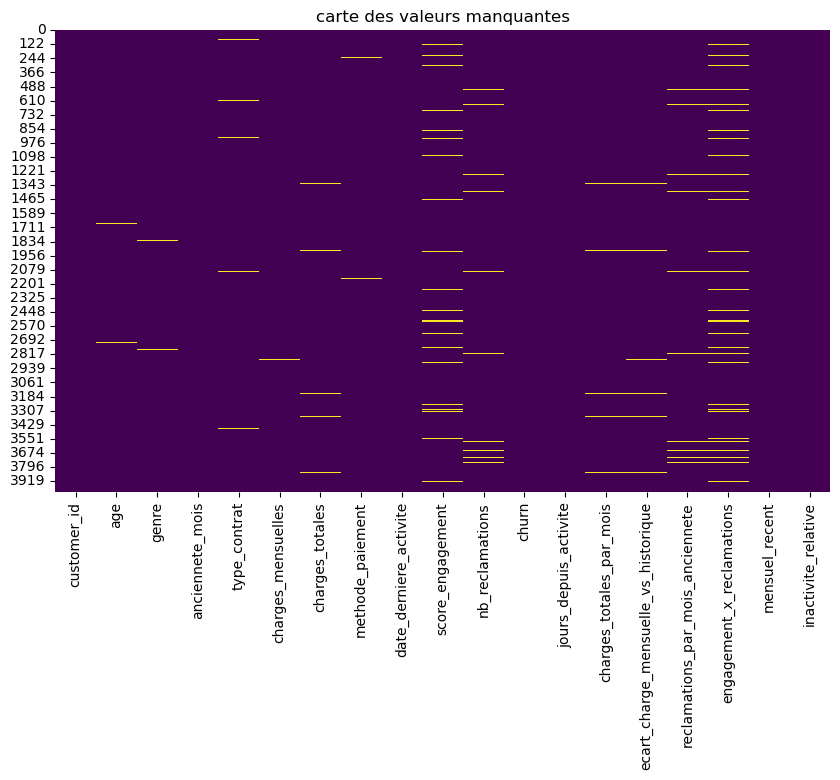

 ANALYSE: présence de valeurs manquantes sur age (31), charges_mensuelles (5), charges_totales (42), date_derniere_activite (6),
 score_engagement (120) et nb_reclamations (80), ainsi que sur genre, type_contrat et methode_paiement suite au nettoyage structurel. 

 NOTE: les 6 features creees (charges_totales_par_mois, ecart_charge_mensuelle_vs_historique,
 reclamations_par_mois_anciennete, engagement_x_reclamations, mensuel_recent, inactivite_relative) heritent
 des valeurs manquantes de leurs colonnes sources (age, charges_totales, score_engagement, nb_reclamations).
 Elles seront imputees de la meme maniere dans le Pipeline, aucun traitement manuel supplementaire n'est necessaire. 

 DÉCISION: convertir date_derniere_activite en nombre de jours depuis une date de référence (transformation déterministe, sans fuite), puis reporter l'imputation des valeurs manquantes restantes (médiane pour les numériques, constante 0 pour nb_reclamations, mode pour les catégorielles) 
DANS le Pipeline

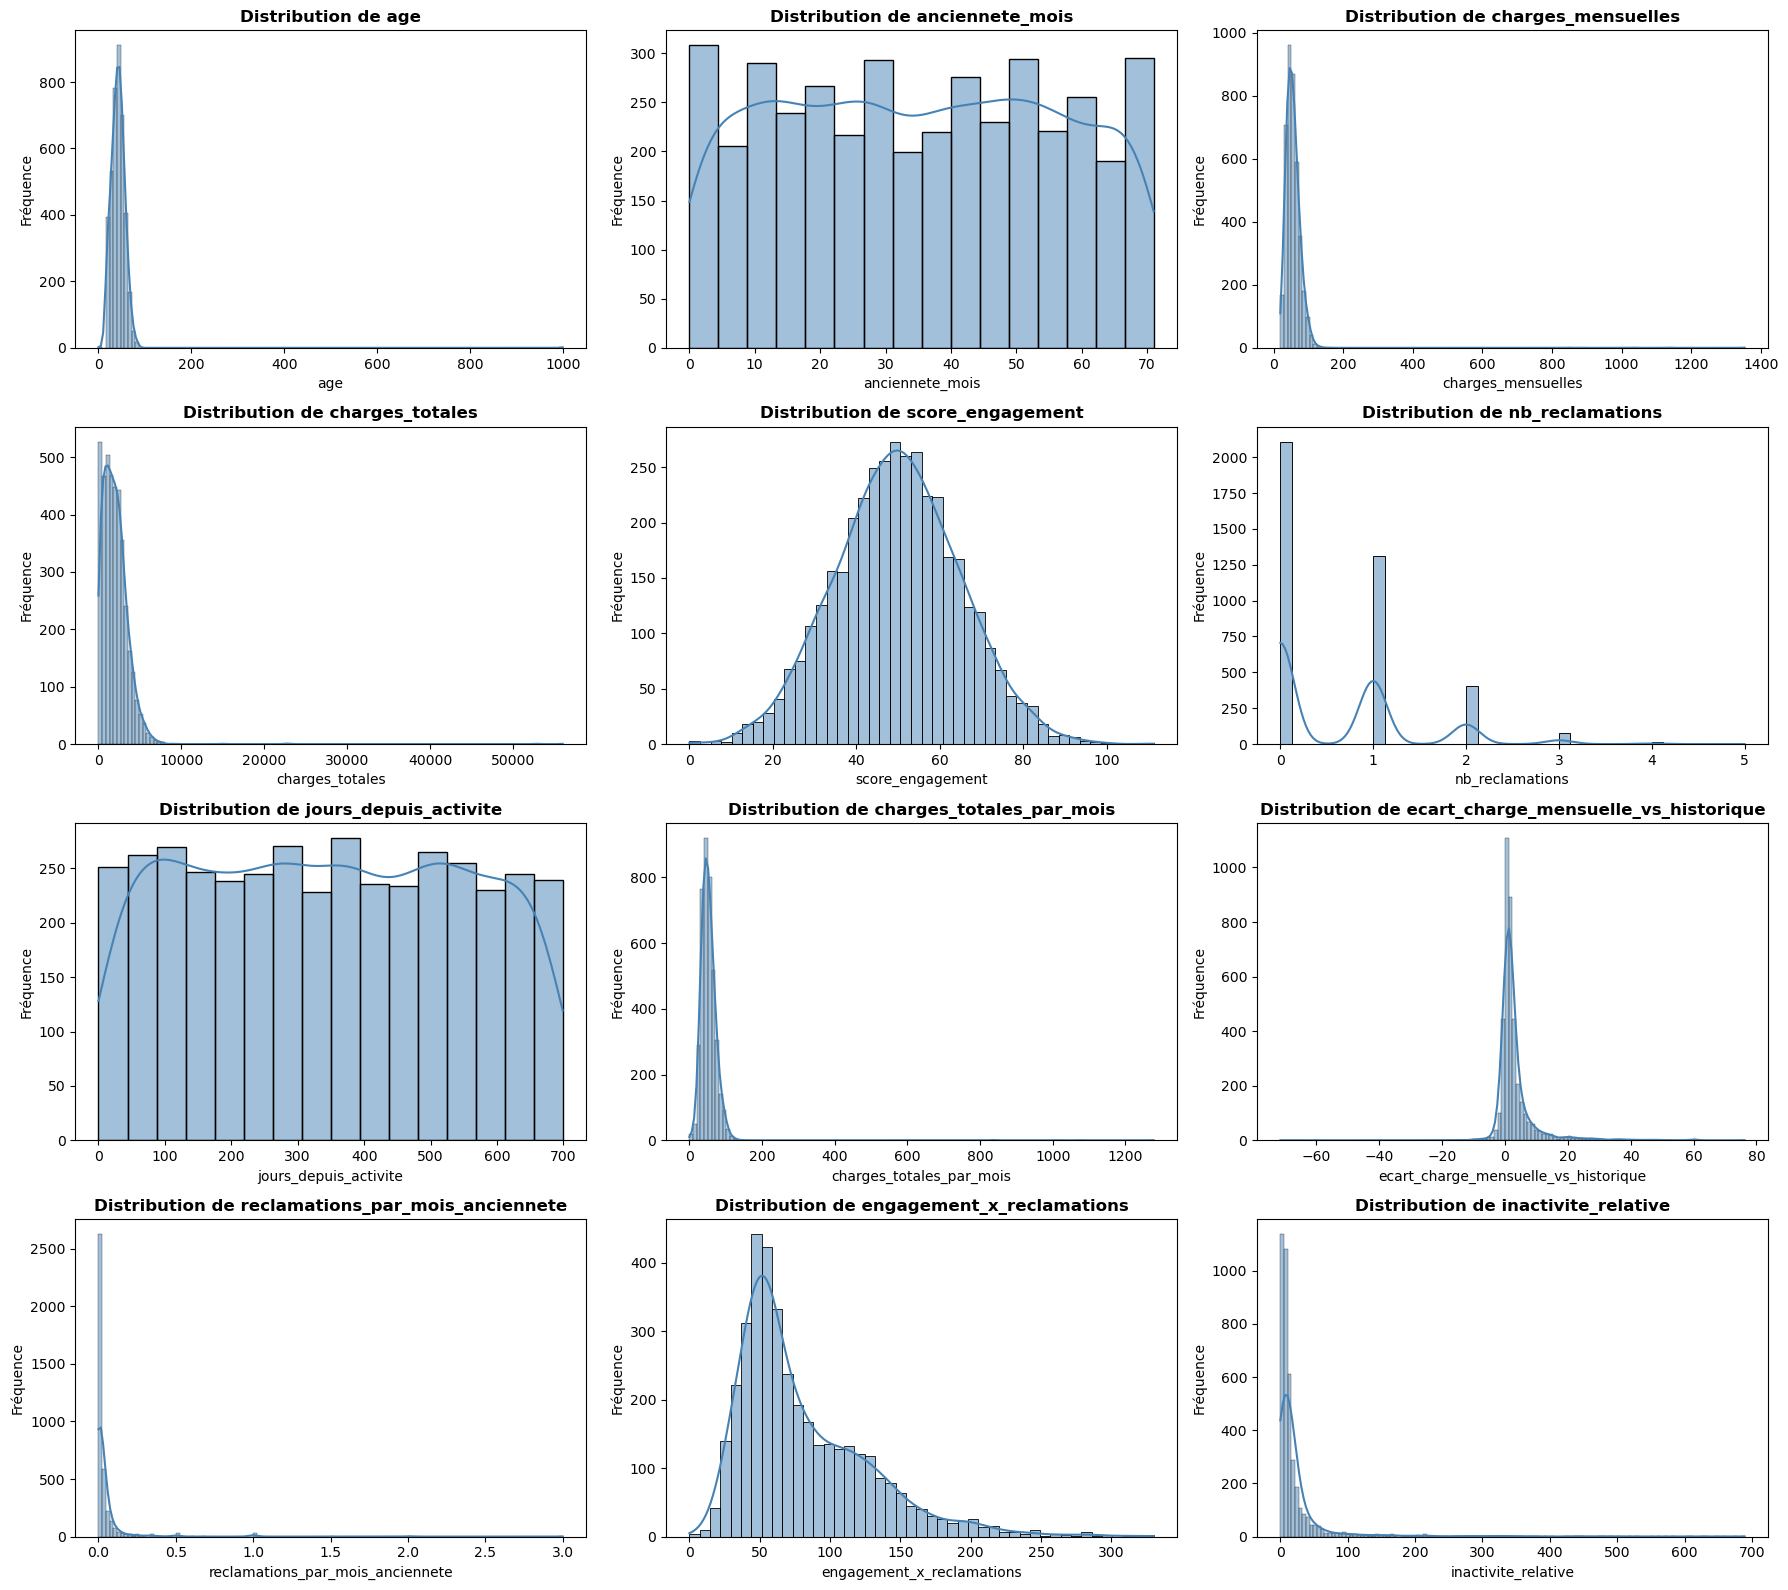

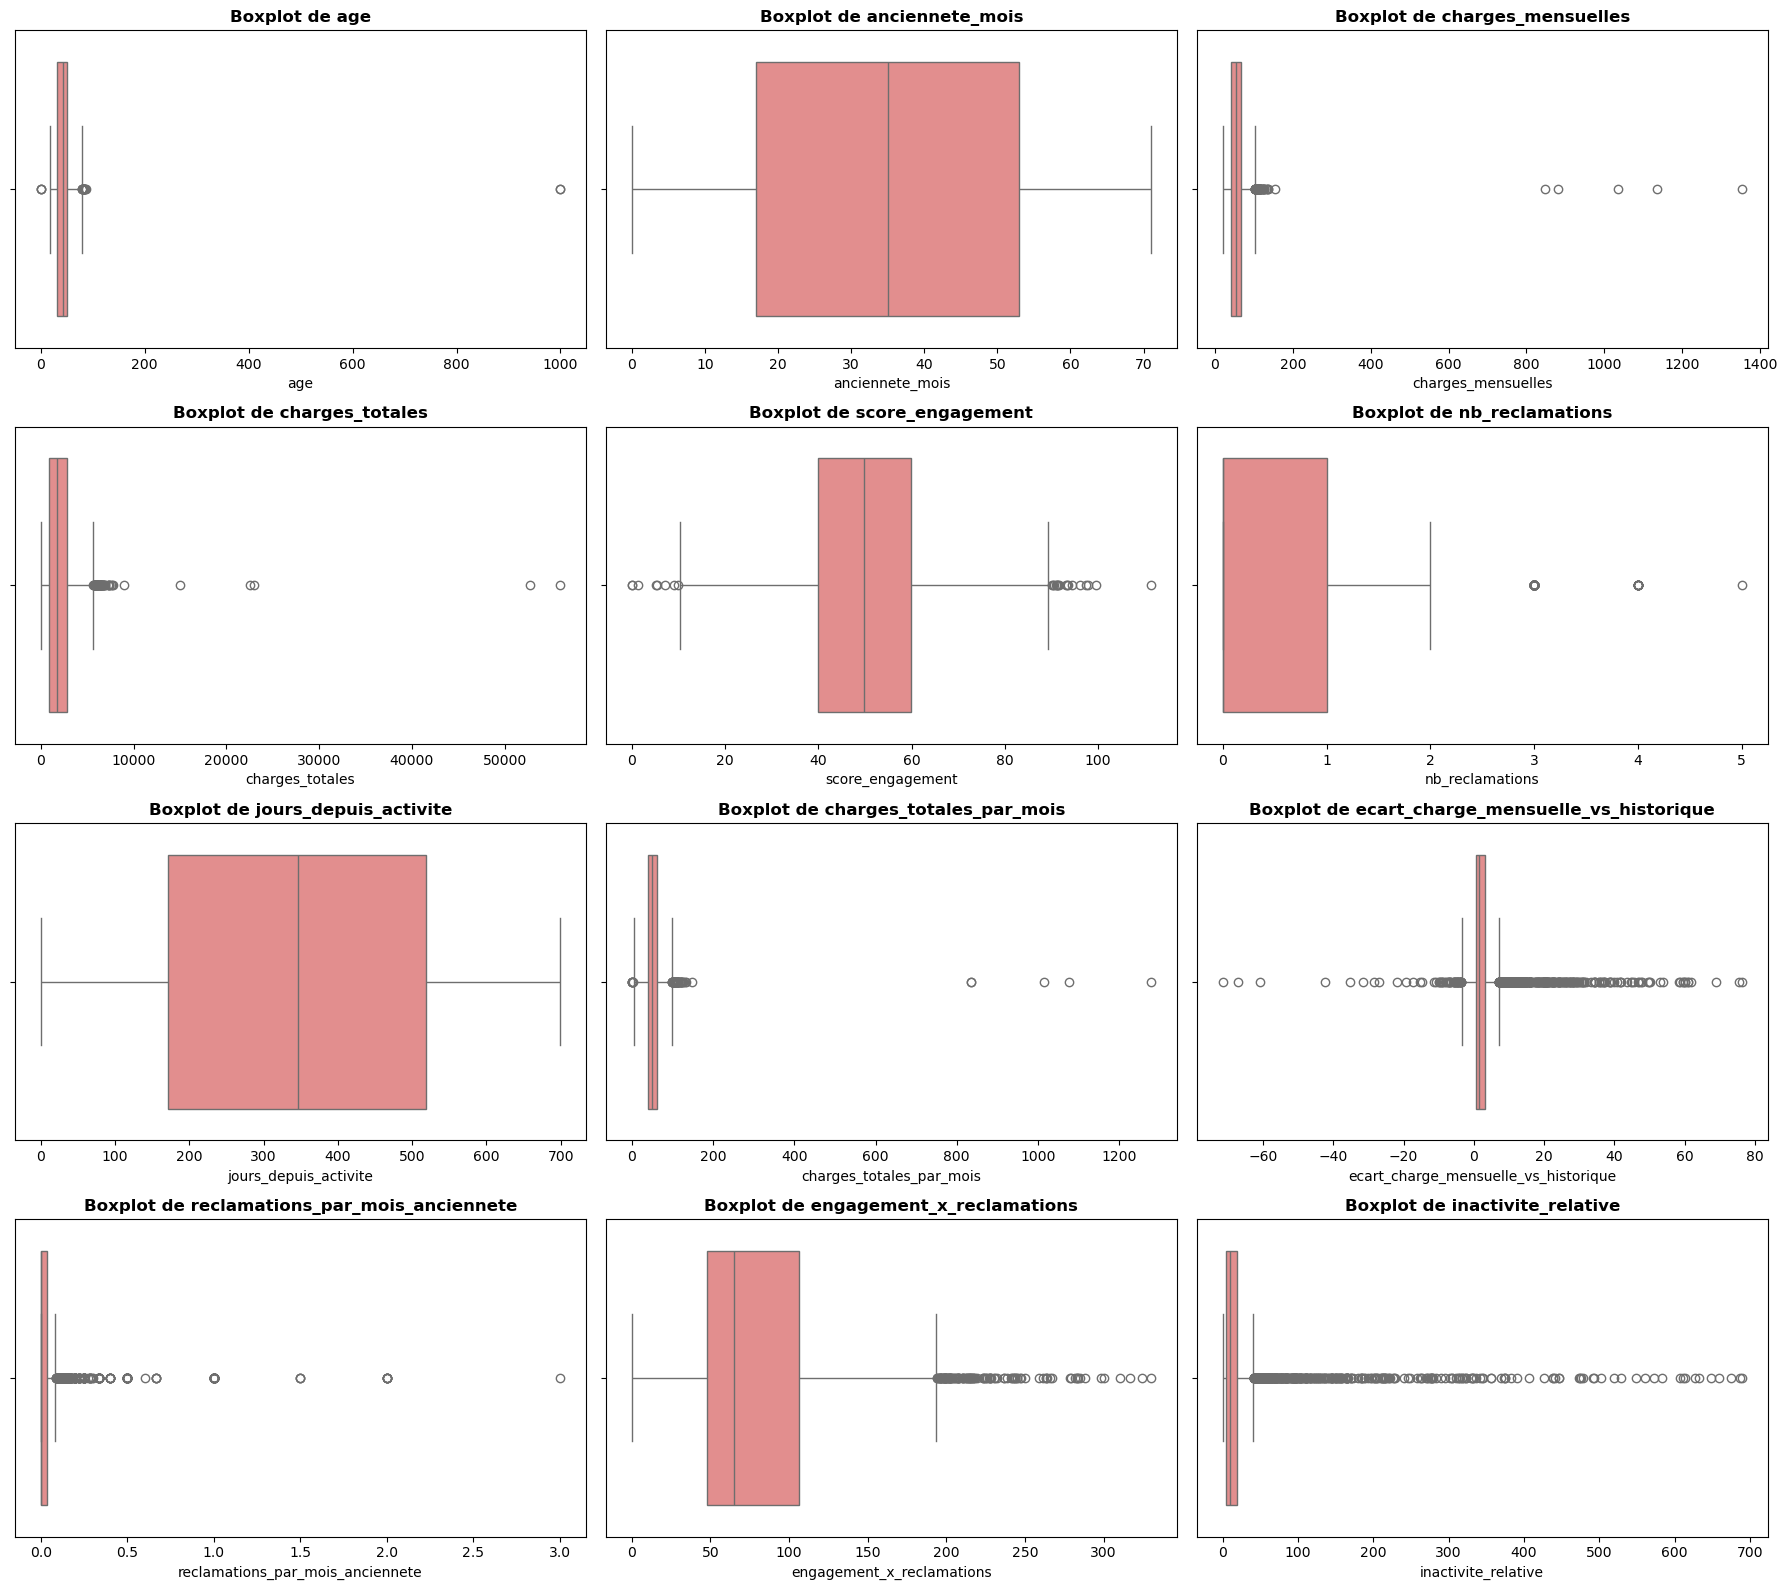

,symetrie,valeurs_aberrantes
age,Asymétrique,Oui
anciennete_mois,Symétrique,Non
charges_mensuelles,Asymétrique,Oui
charges_totales,Asymétrique,Oui
score_engagement,Symétrique,Oui
nb_reclamations,Asymétrique,Oui
jours_depuis_activite,Symetrie,Non
charges_totales_par_mois,Asymétrique,Oui
ecart_charge_mensuelle_vs_historique,Asymétrique,Oui
reclamations_par_mois_anciennete,Asymétrique,Oui


,colonne,Q1,Q3,IQR,borne_basse,borne_haute,nb_outliers
0,age,32.00,51.00,19.00,3.50,79.50,23
1,anciennete_mois,17.00,53.00,36.00,-37.00,107.00,0
2,charges_mensuelles,41.88,65.94,24.06,5.78,102.04,73
3,charges_totales,886.30,2787.24,1900.94,-1965.12,5638.65,61
4,score_engagement,39.98,59.90,19.92,10.09,89.79,25
5,nb_reclamations,0.00,1.00,1.00,-1.50,2.50,92
6,jours_depuis_activite,171.00,519.00,348.00,-351.00,1041.00,0
7,charges_totales_par_mois,39.22,63.24,24.02,3.19,99.28,72
8,ecart_charge_mensuelle_vs_historique,0.50,3.18,2.68,-3.51,7.19,481
9,reclamations_par_mois_anciennete,0.00,0.03,0.03,-0.05,0.08,378


 ANALYSE: les colonnes ['age', 'charges_mensuelles', 'charges_totales', 'score_engagement', 'nb_reclamations', 'charges_totales_par_mois', 'ecart_charge_mensuelle_vs_historique', 'reclamations_par_mois_anciennete', 'engagement_x_reclamations', 'inactivite_relative'] contiennent des valeurs aberrantes détectées par la méthode IQR. 



,symetrie,valeurs_aberrantes,methode_normalisation,justification
age,Asymétrique,Oui,RobustScaler,"Skewness fort , RobustScaler utilise médiane/IQR, insensible aux extrêmes"
anciennete_mois,Symétrique,Non,StandardScaler ou RobustScaler,"Distribution propre et symétrique, sans outliers -> StandardScaler (moyenne/écart-type) adapté ou RobustScaler parce qu'en production la colonne peu devenir asymetrique donc je vais utiliser RobustScaler"
charges_mensuelles,Asymétrique,Oui,RobustScaler,Skewness très fort + outliers extrêmes -> RobustScaler recommandé pour limiter leur influence
charges_totales,Asymétrique,Oui,RobustScaler,"Même profil que charges_mensuelles (dérivée), fortement asymétrique avec outliers"
score_engagement,Symétrique,Oui,RobustScaler,Distribution symétrique mais présence d'outliers -> RobustScaler reste plus prudent que StandardScaler
nb_reclamations,Asymétrique,Oui,RobustScaler,Variable de comptage asymétrique avec outliers -> RobustScaler adapté (alternative: transformation log avant scaling)
jours_depuis_activite,Symétrique,Non,RobustScaler,Variable de comptage symétrique et pas outliers pas de problemes a ce niveau mais si nous anticipons les problemes d'outliers apres deploiement je prendrai cette decision ---- RobustScaler sur la colonne malgré que actuellement il n'y a pas de soucis
charges_totales_par_mois,Asymétrique,Oui,RobustScaler,Ratio derive de charges_totales (deja asymetrique avec outliers) -> RobustScaler par coherence et prudence
ecart_charge_mensuelle_vs_historique,Asymétrique,Oui,RobustScaler,"Difference de deux variables asymetriques (charges_mensuelles, charges_totales_par_mois) -> RobustScaler recommande"
reclamations_par_mois_anciennete,Asymétrique,Oui,RobustScaler,Derive de nb_reclamations (comptage asymetrique) -> meme traitement que la colonne source


C:\Users\new\AppData\Local\Temp\ipykernel_13476\2980033968.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=da[col], ax=axes[i], palette="Set2", order=da[col].value_counts().index)
C:\Users\new\AppData\Local\Temp\ipykernel_13476\2980033968.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=da[col], ax=axes[i], palette="Set2", order=da[col].value_counts().index)
C:\Users\new\AppData\Local\Temp\ipykernel_13476\2980033968.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=da[col], ax=axes[i], palette="Set2", order=da[col]

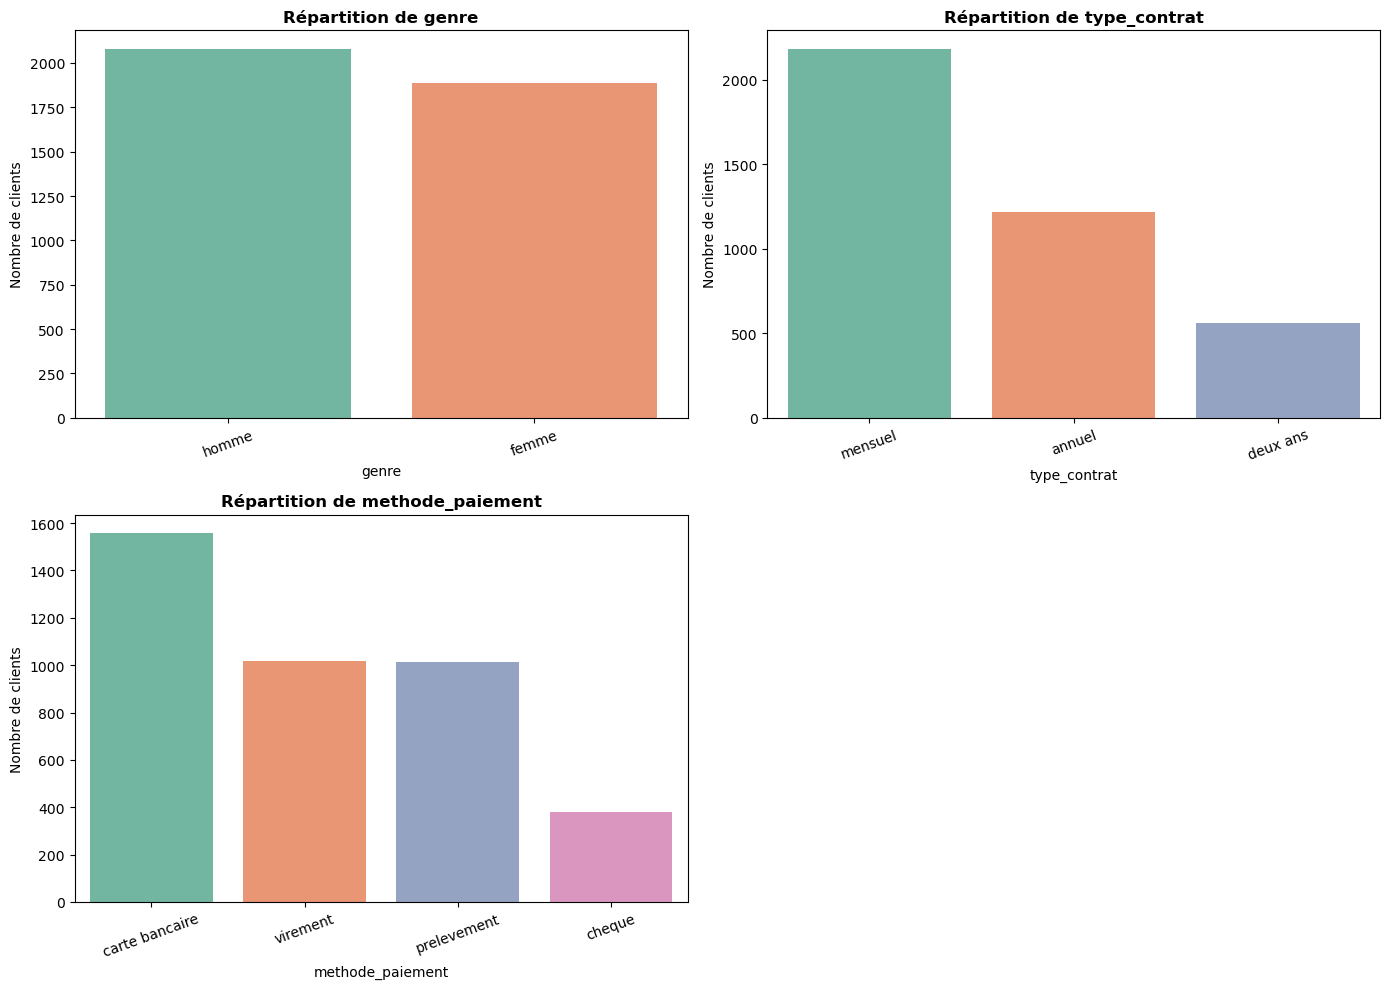

,nb_categories,categorie_dominante,ordre_logique,methode_encodage,justification
genre,2,homme (~52%),Non,OneHotEncoder,"Variable nominale (pas d'ordre entre homme/femme), peu de catégories -> OneHotEncoder adapté sans exploser la dimensionnalité"
type_contrat,3,mensuel (~55%),Oui (mensuel < annuel < deux ans en durée),OneHotEncoder (ou OrdinalEncoder si on veut exploiter l'ordre),"Il existe un ordre naturel (durée d'engagement croissante), mais RandomForest capte déjà bien les interactions avec OneHot -> OneHotEncoder reste le choix le plus sûr, OrdinalEncoder envisageable pour un modèle linéaire"
methode_paiement,4,carte bancaire (~40%),Non,OneHotEncoder,"Variable nominale sans ordre logique, peu de catégories -> OneHotEncoder adapté"


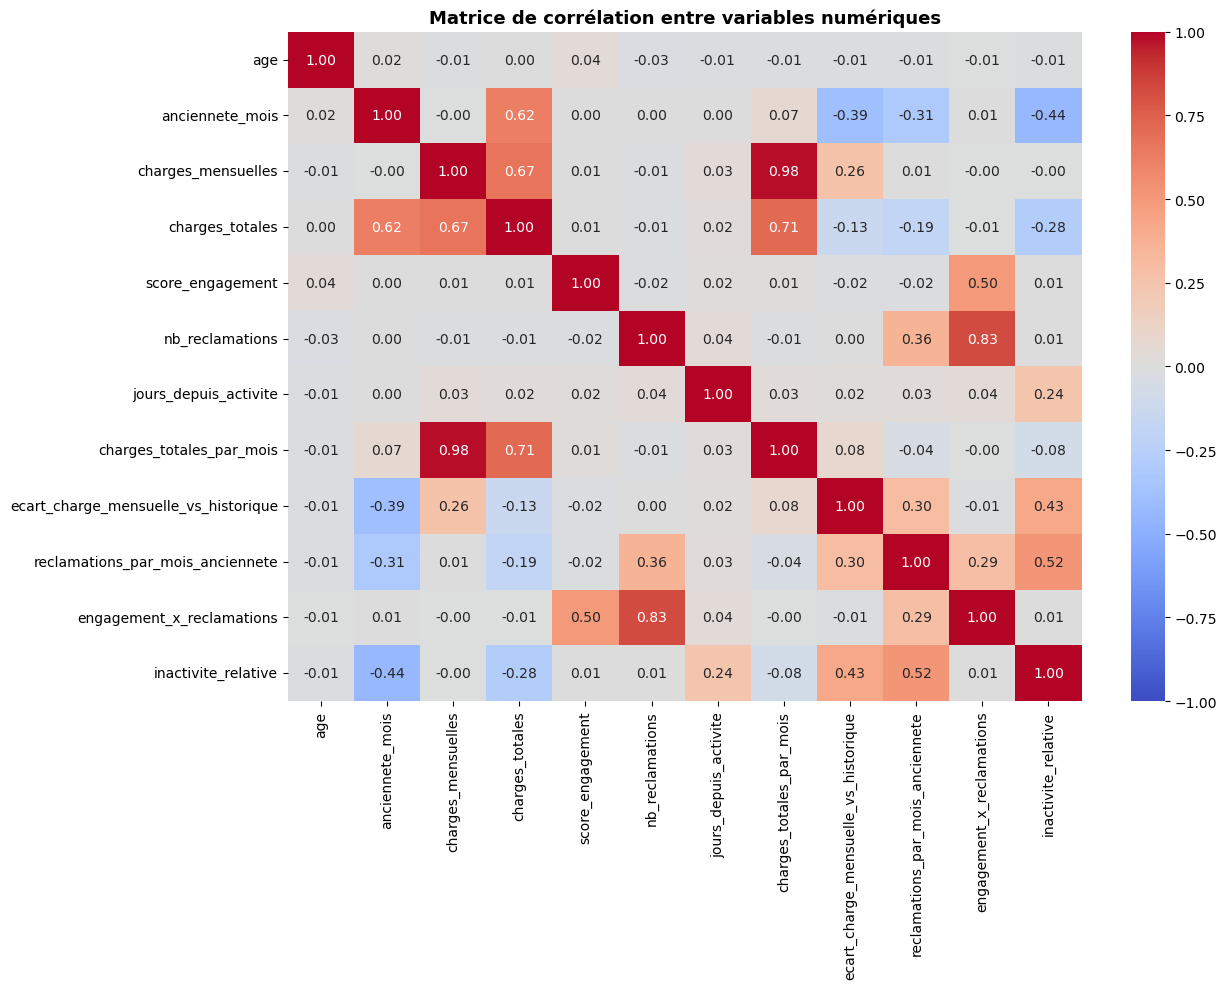

 ANALYSE: paires de variables corrélées (0.5) : [('anciennete_mois', 'charges_totales', np.float64(0.62)), ('charges_mensuelles', 'charges_totales', np.float64(0.67)), ('charges_mensuelles', 'charges_totales_par_mois', np.float64(0.98)), ('charges_totales', 'charges_totales_par_mois', np.float64(0.71)), ('nb_reclamations', 'engagement_x_reclamations', np.float64(0.83)), ('reclamations_par_mois_anciennete', 'inactivite_relative', np.float64(0.52))] 



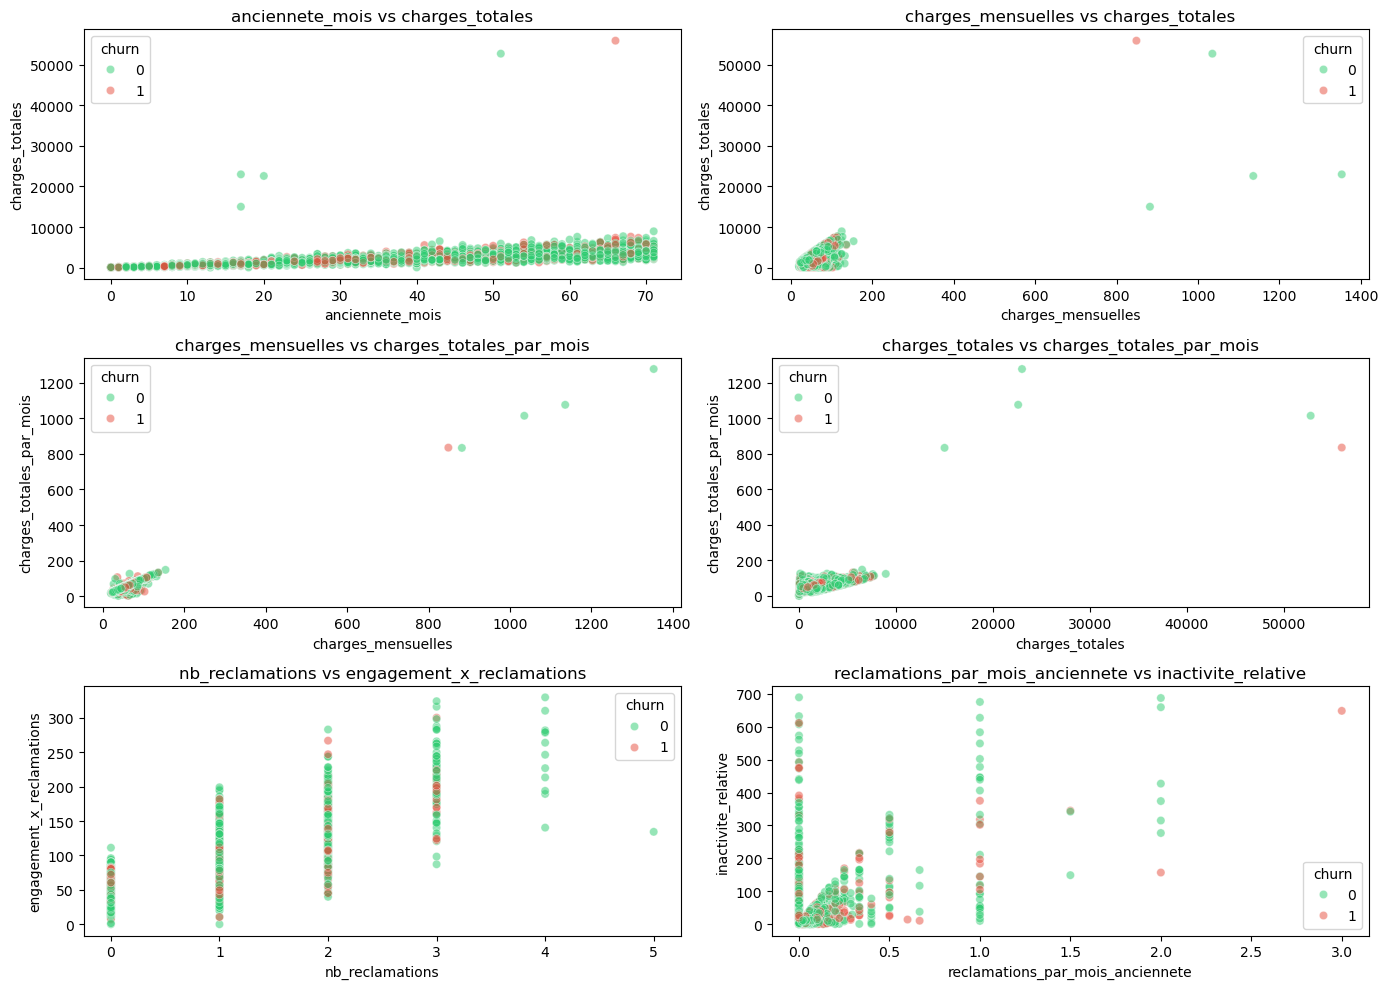

 DÉCISION: outre la colinéarité déjà identifiée entre charges_totales, charges_mensuelles et anciennete_mois, les nouvelles variables engineerées reproduisent mécaniquement cette colinéarité puisqu'elles en sont dérivées : charges_totales_par_mois (dérivée de charges_totales et anciennete_mois), ecart_charge_mensuelle_vs_historique (dérivée de charges_mensuelles et charges_totales_par_mois), reclamations_par_mois_anciennete et engagement_x_reclamations (dérivées de nb_reclamations), ainsi que inactivite_relative (dérivée de jours_depuis_activite). Ce n'est pas un défaut de conception mais une conséquence attendue du feature engineering : ces ratios visent à capturer une information relative que les colonnes brutes ne portent pas seules. Plutôt que de retirer manuellement les colonnes redondantes, on laisse SelectKBest arbitrer automatiquement dans le Pipeline, recalculé à chaque fold, entre variable brute et variable dérivée selon leur pouvoir discriminant réel vis-à-vis du churn. 



age        anciennete_mois        charges_mensuelles         \
        mean median            mean median               mean median   
churn                                                                  
0      42.61   42.0           35.38   36.0              56.72  52.86   
1      41.85   42.0           33.99   34.0              56.82  52.54   

      charges_totales          score_engagement         ...  \
                 mean   median             mean median  ...   
churn                                                   ...   
0             2013.96   1813.6            49.98   50.0  ...   
1             1992.54  1714.31            49.73   49.2  ...   

      charges_totales_par_mois        ecart_charge_mensuelle_vs_historique  \
                          mean median                                 mean   
churn                                                                        
0                         53.6  50.26                                 3.07   
1                        53.66  49.89                                 3.24   

             reclamations_par_mois_anciennete         \
      median                             mean median   
churn                                                  
0       1.45                             0.04    0.0   
1       1.57                             0.05   0.01   

      engagement_x_reclamations        inactivite_relative         
                           mean median                mean median  
churn                                                              
0                          80.2   64.6               25.42   9.62  
1                         81.89   67.9               26.41   9.61  

[2 rows x 24 columns]

C:\Users\new\AppData\Local\Temp\ipykernel_13476\2980033968.py:381: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=da["churn"], y=da[col], ax=axes[i], palette=["#2ecc71", "#e74c3c"])
C:\Users\new\AppData\Local\Temp\ipykernel_13476\2980033968.py:381: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=da["churn"], y=da[col], ax=axes[i], palette=["#2ecc71", "#e74c3c"])
C:\Users\new\AppData\Local\Temp\ipykernel_13476\2980033968.py:381: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=da["churn"], y=da[col], ax=axes[i], palette=["#2ecc71", "#e74c3c"]

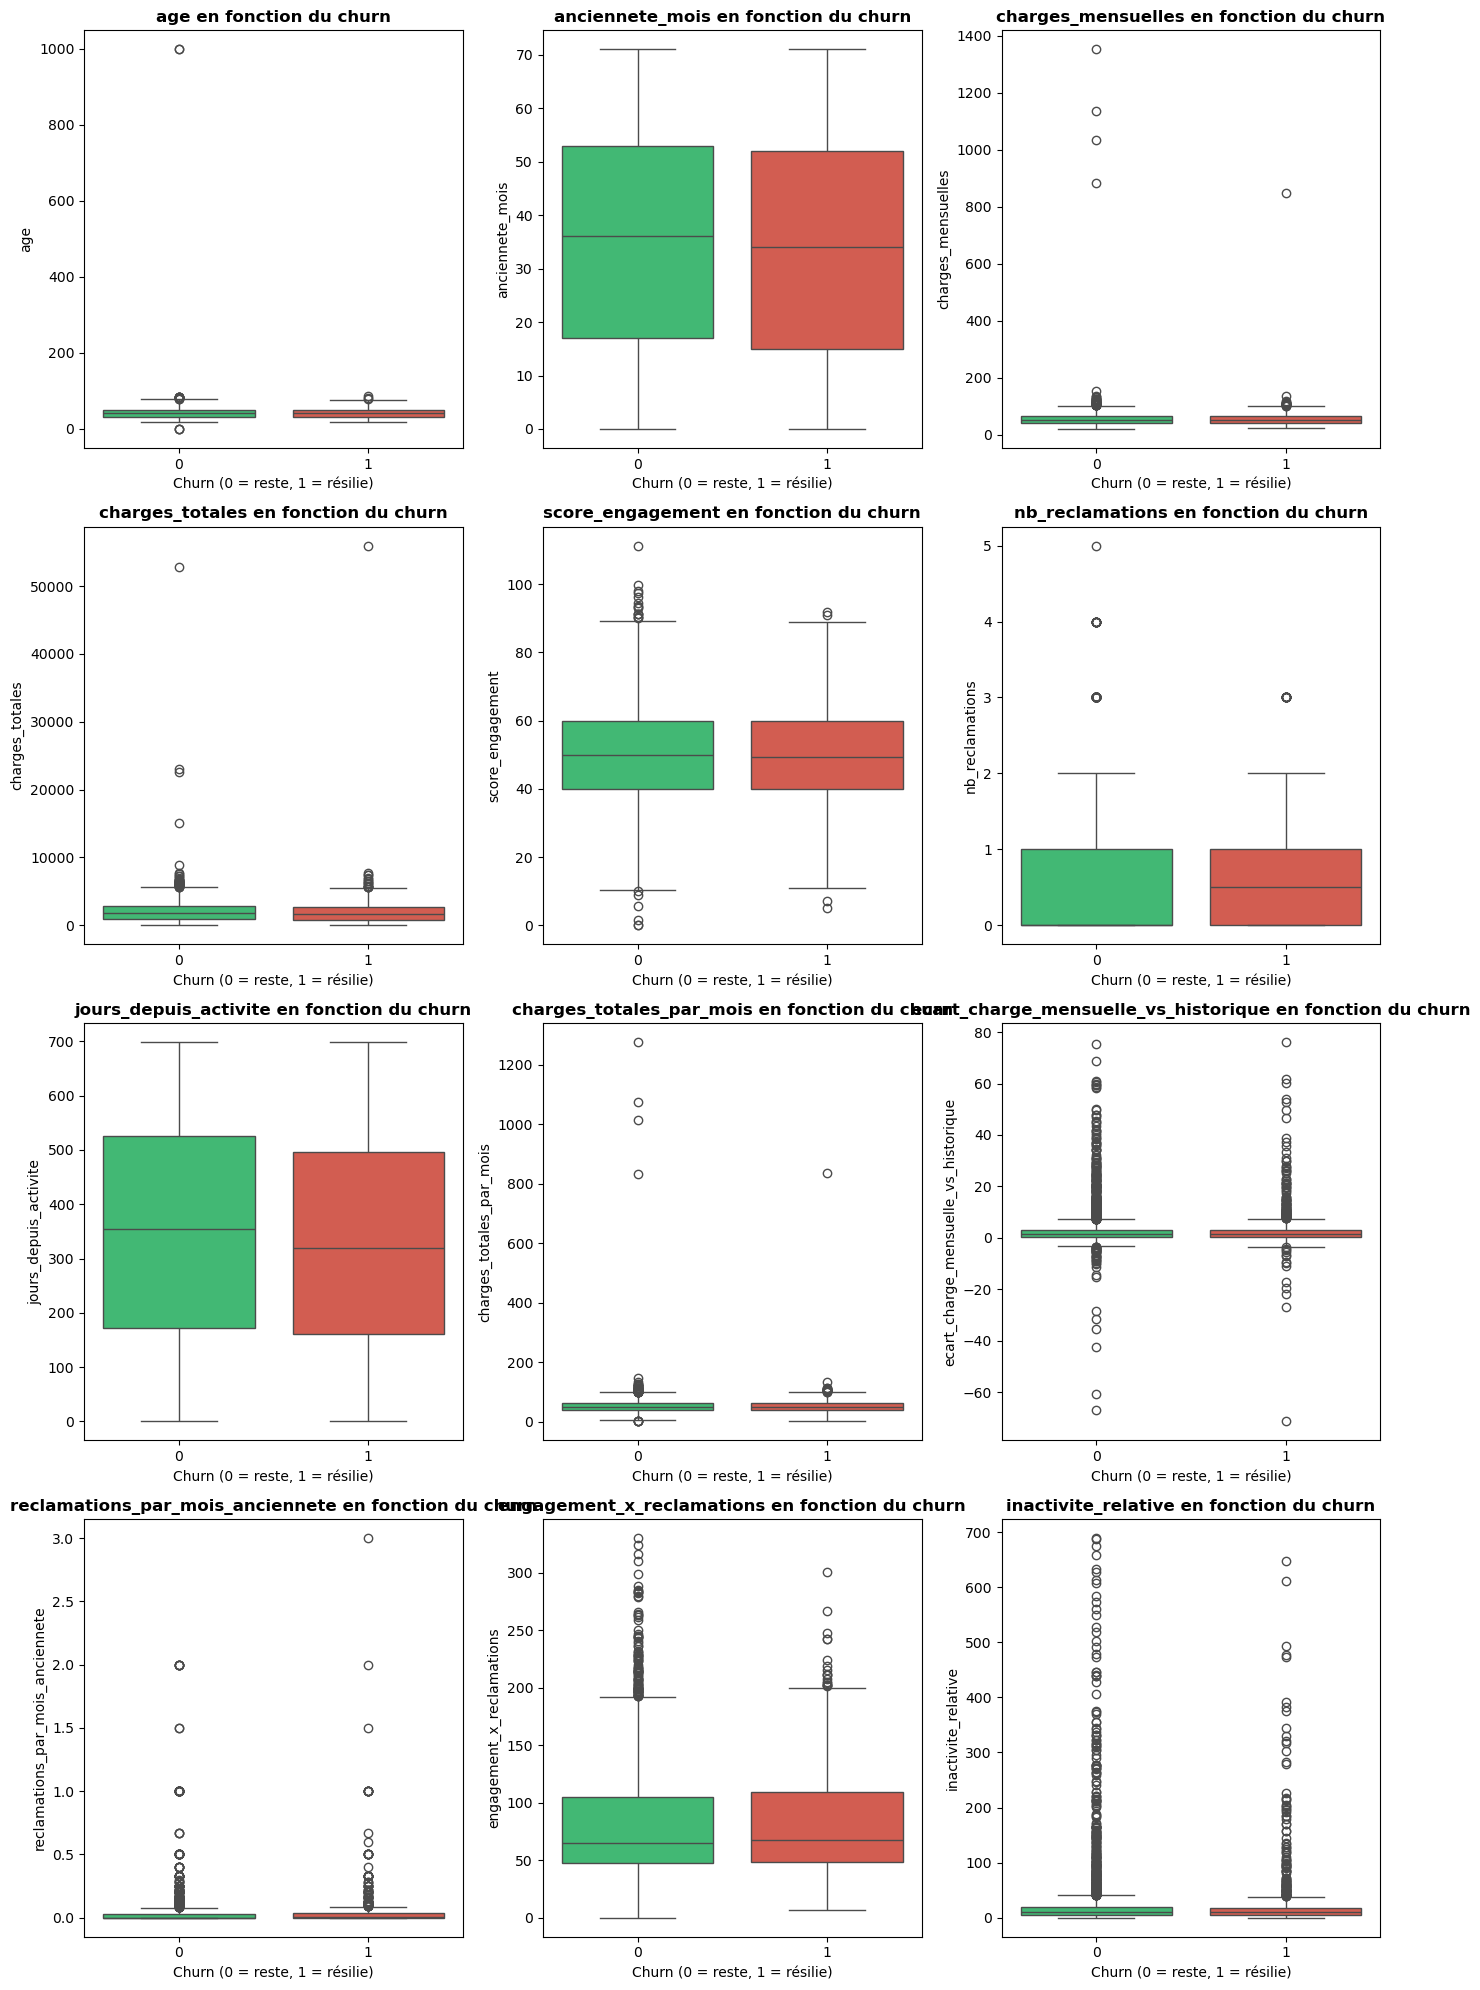

 DÉCISION: en plus de anciennete_mois, charges_mensuelles et nb_reclamations (déjà identifiées comme discriminantes), les nouvelles variables dérivées méritent la même attention : engagement_x_reclamations et reclamations_par_mois_anciennete (qui amplifient le signal de nb_reclamations), ainsi que inactivite_relative (qui combine jours_depuis_activite et anciennete_mois) sont susceptibles d'apporter un pouvoir discriminant supplémentaire par rapport aux colonnes brutes prises isolément. jours_depuis_activite reste écarté en l'état brut (peu de lien apparent avec le churn), et score_engagement, charges_totales_par_mois ainsi que ecart_charge_mensuelle_vs_historique seront probablement filtrés par SelectKBest faute de lien significatif avec la cible, à confirmer avec le tableau de comparaison mean/median par churn. 



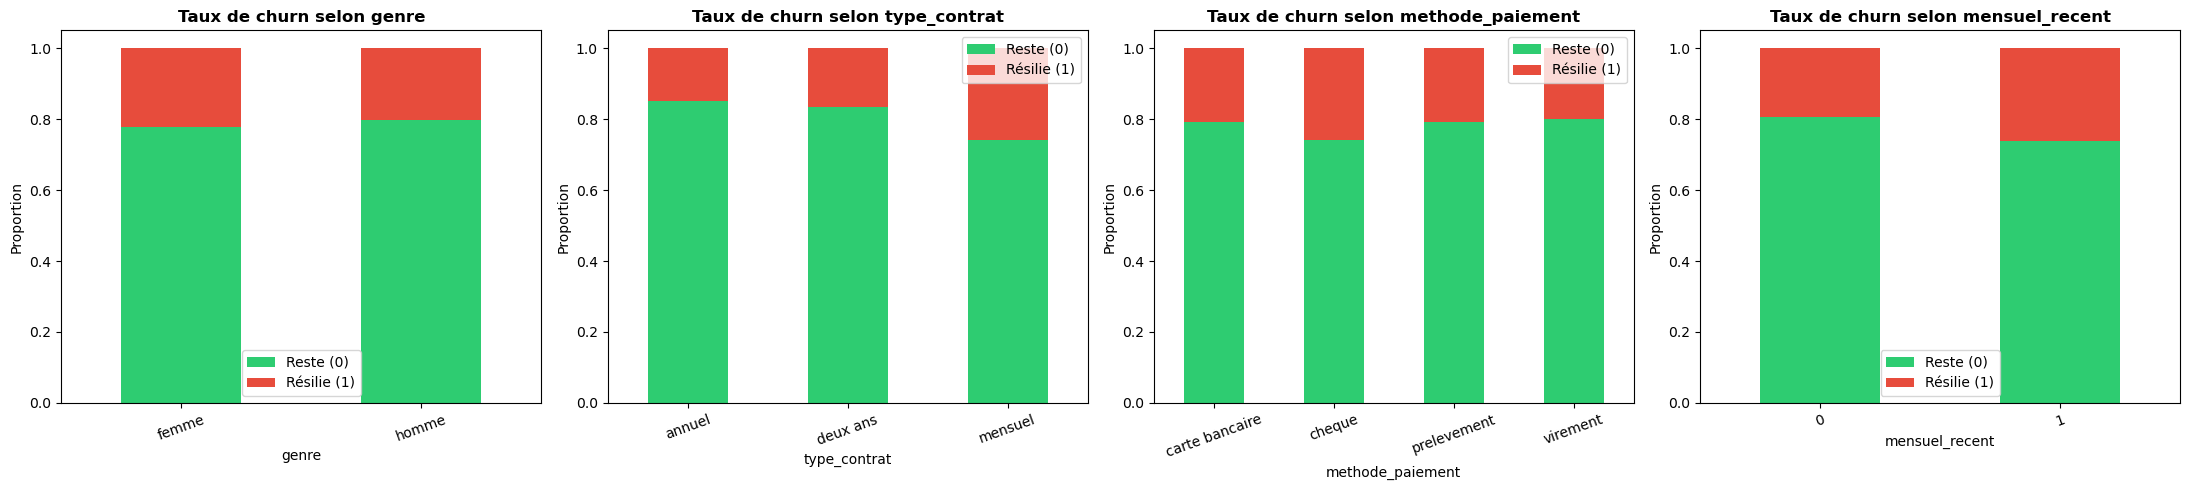

 ANALYSE: test du Chi-2 entre chaque variable catégorielle et churn
genre : p-value = 0.1737 -> relation non significative
type_contrat : p-value = 0.0000 -> relation significative
methode_paiement : p-value = 0.1082 -> relation non significative
mensuel_recent : p-value = 0.0000 -> relation significative
 DÉCISION: type_contrat reste la variable catégorielle la plus discriminante pour le churn (les clients en contrat mensuel résilient davantage), à conserver en priorité. La variable dérivée mensuel_recent, qui combine type_contrat=='mensuel' et une faible ancienneté, est attendue comme potentiellement encore plus discriminante puisqu'elle isole le sous-groupe de clients mensuels récents (les plus volatils). genre et methode_paiement restent sans lien significatif avec le churn -> le SelectKBest ou l'importance des features du RandomForest devrait naturellement leur attribuer un poids faible, à confirmer par le test du Chi-2 recalculé sur les 4 variables catégorielles (genre, type_cont

churn
0    3151
1     849
Name: count, dtype: int64

churn
0    78.8
1    21.2
Name: proportion, dtype: float64


C:\Users\new\AppData\Local\Temp\ipykernel_13476\2980033968.py:446: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=da["churn"], palette=["#2ecc71", "#e74c3c"], ax=axes[0])
C:\Users\new\AppData\Local\Temp\ipykernel_13476\2980033968.py:448: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Reste (0)", "Résilie (1)"])


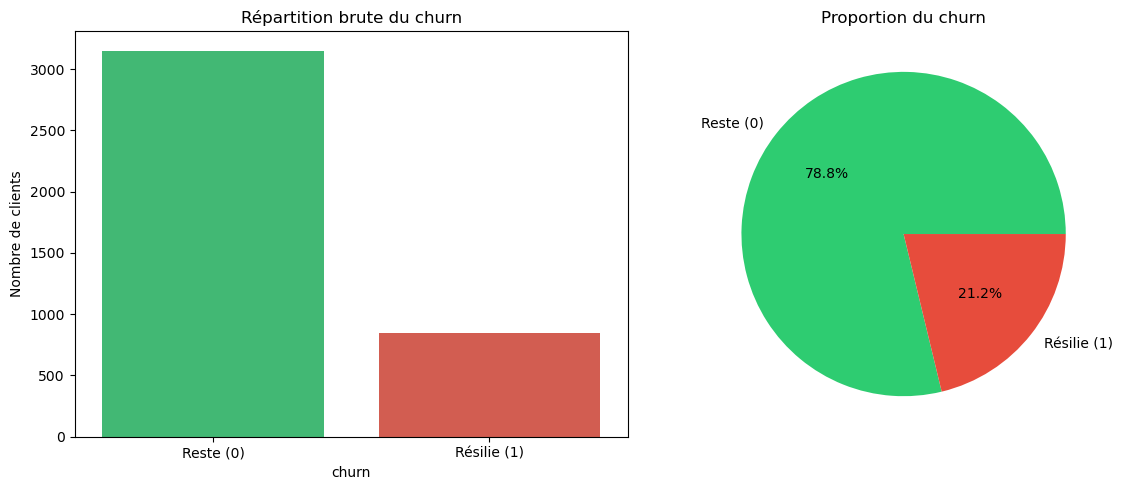

 ANALYSE: la variable cible churn est déséquilibrée -> 21.2% des clients ont résilié (classe minoritaire) contre 78.8% qui sont restés (classe majoritaire). Ce déséquilibre, s'il n'est pas traité, risque de biaiser le modèle vers la prédiction systématique de la classe majoritaire (accuracy trompeuse). 

 DÉCISION: privilégier le F1-score ou le ROC AUC plutôt que l'accuracy pour évaluer le modèle (l'accuracy serait artificiellement élevée même en prédisant toujours 'reste'). Comparer 3 stratégies dans la cross-validation : modèle normal (baseline), class_weight='balanced', et SMOTE (dans un Pipeline imblearn pour éviter la fuite), afin de choisir celle qui gère le mieux ce déséquilibre. 

 DÉCISION: retenir SimpleImputer (médiane pour les numériques, mode pour les catégorielles, constante 0 pour nb_reclamations), RobustScaler pour toutes les colonnes numériques asymétriques/avec outliers -- y compris les 5 nouvelles variables dérivées (charges_totales_par_mois, ecart_charge_mensuelle_v

In [17]:


display(HTML("<h1 style='font-size:36px;text-align:center;'>EDA(ANALYSE EXPLORATRICE DES DONNEES)</h1>"))



#Resumé statistiques global
display(HTML("<h1 style='font-size:20px;color:blue;'>Resumé statistiques global</h1>"))
num_desc=da.describe()
cate_desc=da.describe(include="object")
display(cate_desc)
print("\033[92m Interprétation résumée:\033[0m Sur les colonnes catégorielles, customer_id est bien un identifiant unique (4000 valeurs pour 4000 lignes non-nulles,\naucun doublon restant).\ngenre compte 3967 valeurs renseignées avec 2 catégories (homme/femme), dont homme domine avec 2080 occurrences. type_contrat a 3959 valeurs sur 3 catégories, mensuel étant la plus fréquente (2184 fois, soit plus de la moitié).\nmethode_paiement compte 3974 valeurs sur 4 catégories, carte bancaire arrivant largement en tête (1558 occurrences).On note quelques valeurs manquantes sur genre , type_contrat  et methode_paiement , à traiter lors du nettoyage approfondi.")
print("\033[94m En résumé, le profil type du client dans ce dataset est majoritairement des hommes qui ont l'habitude de payer mensuellement avec une carte bancaire.\033[0m \n")

display(num_desc)

print("\033[92m Analyse colonne par colonne :\033[0m \nanciennete_mois — skewness ≈ 0, moyenne ≈ médiane, 0% d'outliers IQR. Distribution symétrique et propre, aucune valeur suspecte. C'est la colonne la plus saine.\nscore_engagement — skewness ≈ 0, moyenne ≈ médiane. Distribution quasi symétrique, mais le minimum de -4 est suspect (un score censé être positif) — à vérifier, potentiel outlier isolé plutôt qu'un vrai problème de distribution.\n\nage — skewness énorme (26.91), à cause du max à 999 et du min à -5. Ce ne sont pas des valeurs réelles, ce sont des erreurs de saisie évidentes (personne n'a 999 ans ou -5 ans). Sans ces quelques valeurs extrêmes, la distribution serait probablement bien plus symétrique (l'écart moyenne/médiane est faible : 42.41 vs 42.00).\ncharges_mensuelles — skewness très élevé (20.79) et écart-type énorme par rapport à la moyenne, à cause du max à 1353 et du min négatif à -75. Distribution naturellement asymétrique à droite (une facture ne peut pas être négative), amplifiée fortement par des outliers extrêmes.\ncharges_totales — même situation : skewness fort (11.93), max délirant (55 965) alors que la moyenne est à ~1988. La médiane (1770) beaucoup plus basse que la moyenne confirme une distribution tirée vers la droite par quelques valeurs extrêmes.\nnb_reclamations — skewness modéré (1.23), cohérent avec sa nature : c'est un comptage (Poisson), donc la plupart des clients ont 0 réclamation et quelques-uns en ont plus — asymétrie normale et attendue pour ce type de variable, pas une erreur.")

print("\033[94m DECISION: Gerer les valeurs incoherentes négatifs observer dans les colonnes(age,charges_mensuelles,charges_totales,score_engagement.) \033[0m \n")
print("\033[94m DECISION FUTUR:Du fait qu'un client peut ne pas faire de reclamations,\nles valeurs manquantes de cette colonne sont significatifs et seront remplacés par 0\033[0m \n")




#Gestion des valeurs incoherentes
display(HTML("<h1 style='font-size:20px;color:green;'>Gestion des valeurs incoherentes</h1>"))
print("Ages négatifs :", (da["age"] < 0).sum())
print("Charges mensuelles négatives :", (da["charges_mensuelles"]<0).sum())
print("Charges totales négatives :", (da["charges_totales"] < 0).sum())
print("Valeurs négatives dans score_engagement :", (da["score_engagement"] < 0).sum())

da.loc[da["age"] < 0, "age"] = np.nan
da.loc[da["charges_mensuelles"] < 0, "charges_mensuelles"] = np.nan
da.loc[da["charges_totales"] < 0, "charges_totales"] = np.nan
print(da.loc[da["score_engagement"] < 0, "score_engagement"])
da["score_engagement"] = da["score_engagement"].clip(lower=0)
display(da.describe())


# creation de features supplementaires (ratios et interactions)
# -> placees ICI (apres la correction des valeurs incoherentes) et non avant,
# pour ne pas calculer des ratios a partir d'ages/charges/scores encore errones
display(HTML("<h1 style='font-size:20px;color:green;'>Feature engineering - ratios et interactions</h1>"))

# Ratio charge moyenne reelle par mois d'anciennete
# (permet de detecter des ecarts entre charges_mensuelles declarees et l'historique reel)
da["charges_totales_par_mois"] = da["charges_totales"] / (da["anciennete_mois"] + 1)

# Ecart entre la charge mensuelle actuelle et la charge moyenne historique
# -> capte une hausse ou baisse recente de facturation, signal potentiel de churn
da["ecart_charge_mensuelle_vs_historique"] = da["charges_mensuelles"] - da["charges_totales_par_mois"]

# Reclamations rapportees a l'anciennete (un client recent qui reclame beaucoup est plus a risque
# qu'un client ancien avec le meme nombre absolu de reclamations)
da["reclamations_par_mois_anciennete"] = da["nb_reclamations"] / (da["anciennete_mois"] + 1)

# Interaction engagement x reclamations : un engagement faible ET des reclamations frequentes
# est un signal cumulatif plus fort que chaque variable prise separement
da["engagement_x_reclamations"] = da["score_engagement"] * (da["nb_reclamations"] + 1)

# Interaction anciennete x type de contrat mensuel : un client mensuel avec peu d'anciennete
# est structurellement plus volatile qu'un client mensuel ancien
da["mensuel_recent"] = np.where(
    (da["type_contrat"] == "mensuel") & (da["anciennete_mois"] < da["anciennete_mois"].median()),
    1, 0
)

# Inactivite relative a l'anciennete : un client recent inactif depuis longtemps est plus suspect
# qu'un client ancien avec le meme nombre absolu de jours d'inactivite
da["inactivite_relative"] = da["jours_depuis_activite"] / (da["anciennete_mois"] + 1)

nouvelles_features = [
    "charges_totales_par_mois", "ecart_charge_mensuelle_vs_historique",
    "reclamations_par_mois_anciennete", "engagement_x_reclamations",
    "mensuel_recent", "inactivite_relative"
]
display(da[nouvelles_features].describe())




#Detection des valeurs manquantes
display(HTML("<h1 style='font-size:20px;color:blue;'>Detection des valeurs manquantes</h1>"))
display(da.isnull().mean()*100)
plt.figure(figsize=(10,6))
sns.heatmap(da.isnull(),cbar=False,cmap="viridis")
plt.title("carte des valeurs manquantes")
plt.show()
print("\033[91m ANALYSE: présence de valeurs manquantes sur age (31), charges_mensuelles (5), charges_totales (42), date_derniere_activite (6),\n score_engagement (120) et nb_reclamations (80), ainsi que sur genre, type_contrat et methode_paiement suite au nettoyage structurel.\033[0m \n")
print("\033[91m NOTE: les 6 features creees (charges_totales_par_mois, ecart_charge_mensuelle_vs_historique,\n reclamations_par_mois_anciennete, engagement_x_reclamations, mensuel_recent, inactivite_relative) heritent\n des valeurs manquantes de leurs colonnes sources (age, charges_totales, score_engagement, nb_reclamations).\n Elles seront imputees de la meme maniere dans le Pipeline, aucun traitement manuel supplementaire n'est necessaire.\033[0m \n")

print("\033[94m DÉCISION: convertir date_derniere_activite en nombre de jours depuis une date de référence (transformation déterministe, sans fuite), puis reporter l'imputation des valeurs manquantes restantes (médiane pour les numériques, constante 0 pour nb_reclamations, mode pour les catégorielles) \nDANS le Pipeline sklearn via SimpleImputer, afin qu'elle soit recalculée uniquement sur les données d'entraînement de chaque fold et\névite toute fuite de données.\033[0m \n")






#Analyse univariee -variables numeriques
display(HTML("<h1 style='font-size:20px;color:blue;'>Analyse univariee - variables numeriques</h1>"))

num_cols = ["age", "anciennete_mois", "charges_mensuelles", "charges_totales", "score_engagement", "nb_reclamations", "jours_depuis_activite", "charges_totales_par_mois", "ecart_charge_mensuelle_vs_historique", "reclamations_par_mois_anciennete", "engagement_x_reclamations", "inactivite_relative"]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))
axes = axes.flatten()  # transforme la grille 2D en liste 1D pour itérer facilement

for i, col in enumerate(num_cols):
    sns.histplot(da[col].dropna(), kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution de {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Fréquence")
                                         # cacher les axes vides restants 
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=da[col].dropna(), ax=axes[i], color="lightcoral")
    axes[i].set_title(f"Boxplot de {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

dico_symetrie_visuelle = {
    "age": {"symetrie": "Asymétrique", "valeurs_aberrantes": "Oui"},
    "anciennete_mois": {"symetrie": "Symétrique", "valeurs_aberrantes": "Non"},
    "charges_mensuelles": {"symetrie": "Asymétrique", "valeurs_aberrantes": "Oui"},
    "charges_totales": {"symetrie": "Asymétrique", "valeurs_aberrantes": "Oui"},
    "score_engagement": {"symetrie": "Symétrique", "valeurs_aberrantes": "Oui"},
    "nb_reclamations": {"symetrie": "Asymétrique", "valeurs_aberrantes": "Oui"},
    "jours_depuis_activite":{"symetrie":"Symetrie","valeurs_aberrantes":"Non"},
    "charges_totales_par_mois": {"symetrie": "Asymétrique", "valeurs_aberrantes": "Oui"},
    "ecart_charge_mensuelle_vs_historique": {"symetrie": "Asymétrique", "valeurs_aberrantes": "Oui"},
    "reclamations_par_mois_anciennete": {"symetrie": "Asymétrique", "valeurs_aberrantes": "Oui"},
    "engagement_x_reclamations": {"symetrie": "Asymétrique", "valeurs_aberrantes": "Oui"},
    "inactivite_relative": {"symetrie": "Asymétrique", "valeurs_aberrantes": "Oui"},
}

df_visuel = pd.DataFrame.from_dict(dico_symetrie_visuelle, orient="index")
display(df_visuel)







#Detection des Outliers
display(HTML("<h1 style='font-size:20px;color:blue;'>Detection des Outliers </h1>"))

num_cols = ["age", "anciennete_mois", "charges_mensuelles", "charges_totales", "score_engagement", "nb_reclamations", "jours_depuis_activite", "charges_totales_par_mois", "ecart_charge_mensuelle_vs_historique", "reclamations_par_mois_anciennete", "engagement_x_reclamations", "inactivite_relative"]

outliers_recap = []
for col in num_cols:
    s = da[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    borne_basse = q1 - 1.5 * iqr
    borne_haute = q3 + 1.5 * iqr
    mask_outliers = (s < borne_basse) | (s > borne_haute)
    outliers_recap.append({
        "colonne": col,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "borne_basse": round(borne_basse, 2),
        "borne_haute": round(borne_haute, 2),
        "nb_outliers": int(mask_outliers.sum()),
    })

recap_outliers = pd.DataFrame(outliers_recap)
display(recap_outliers)
print(f"\033[91m ANALYSE: les colonnes {recap_outliers.loc[recap_outliers['nb_outliers'] > 0, 'colonne'].tolist()} contiennent des valeurs aberrantes détectées par la méthode IQR.\033[0m \n")

display(HTML("<h1 style='font-size:20px;color:green;'>POUR GERER LES OUTLIERS ET LA DISTRIBUTIONS DEA COLONNES NUMERIQUES</h1>"))
dico_symetrie_visuelle = {
    "age": {
        "symetrie": "Asymétrique",
        "valeurs_aberrantes": "Oui",
        "methode_normalisation": "RobustScaler",
        "justification": "Skewness fort , RobustScaler utilise médiane/IQR, insensible aux extrêmes"
    },
    "anciennete_mois": {
        "symetrie": "Symétrique",
        "valeurs_aberrantes": "Non",
        "methode_normalisation": "StandardScaler ou RobustScaler",
        "justification": "Distribution propre et symétrique, sans outliers -> StandardScaler (moyenne/écart-type) adapté ou RobustScaler parce qu'en production la colonne peu devenir asymetrique donc je vais utiliser RobustScaler"
    },
    "charges_mensuelles": {
        "symetrie": "Asymétrique",
        "valeurs_aberrantes": "Oui",
        "methode_normalisation": "RobustScaler",
        "justification": "Skewness très fort + outliers extrêmes -> RobustScaler recommandé pour limiter leur influence"
    },
    "charges_totales": {
        "symetrie": "Asymétrique",
        "valeurs_aberrantes": "Oui",
        "methode_normalisation": "RobustScaler",
        "justification": "Même profil que charges_mensuelles (dérivée), fortement asymétrique avec outliers"
    },
    "score_engagement": {
        "symetrie": "Symétrique",
        "valeurs_aberrantes": "Oui",
        "methode_normalisation": "RobustScaler",
        "justification": "Distribution symétrique mais présence d'outliers -> RobustScaler reste plus prudent que StandardScaler"
    },
    "nb_reclamations": {
        "symetrie": "Asymétrique",
        "valeurs_aberrantes": "Oui",
        "methode_normalisation": "RobustScaler",
        "justification": "Variable de comptage asymétrique avec outliers -> RobustScaler adapté (alternative: transformation log avant scaling)"
    },
     "jours_depuis_activite": {
        "symetrie": "Symétrique",
        "valeurs_aberrantes": "Non",
        "methode_normalisation": "RobustScaler",
        "justification": "Variable de comptage symétrique et pas outliers pas de problemes a ce niveau mais si nous anticipons les problemes d'outliers apres deploiement  je prendrai cette decision ---- RobustScaler sur la colonne malgré que actuellement il n'y a pas de soucis"
    },
    "charges_totales_par_mois": {
        "symetrie": "Asymétrique",
        "valeurs_aberrantes": "Oui",
        "methode_normalisation": "RobustScaler",
        "justification": "Ratio derive de charges_totales (deja asymetrique avec outliers) -> RobustScaler par coherence et prudence"
    },
    "ecart_charge_mensuelle_vs_historique": {
        "symetrie": "Asymétrique",
        "valeurs_aberrantes": "Oui",
        "methode_normalisation": "RobustScaler",
        "justification": "Difference de deux variables asymetriques (charges_mensuelles, charges_totales_par_mois) -> RobustScaler recommande"
    },
    "reclamations_par_mois_anciennete": {
        "symetrie": "Asymétrique",
        "valeurs_aberrantes": "Oui",
        "methode_normalisation": "RobustScaler",
        "justification": "Derive de nb_reclamations (comptage asymetrique) -> meme traitement que la colonne source"
    },
    "engagement_x_reclamations": {
        "symetrie": "Asymétrique",
        "valeurs_aberrantes": "Oui",
        "methode_normalisation": "RobustScaler",
        "justification": "Interaction impliquant nb_reclamations (asymetrique) -> RobustScaler par prudence"
    },
    "inactivite_relative": {
        "symetrie": "Asymétrique",
        "valeurs_aberrantes": "Oui",
        "methode_normalisation": "RobustScaler",
        "justification": "Ratio divise par anciennete_mois (+1), peut produire des valeurs extremes pour les clients recents -> RobustScaler"
    },
}


df_visuel = pd.DataFrame.from_dict(dico_symetrie_visuelle, orient="index")
display(df_visuel)


#Analyse univariee -variables Categorielles
display(HTML("<h1 style='font-size:20px;color:blue;'>Analyse univariée - Variables catégorielles</h1>"))

cat_cols = ["genre", "type_contrat", "methode_paiement"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=da[col], ax=axes[i], palette="Set2", order=da[col].value_counts().index)
    axes[i].set_title(f"Répartition de {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Nombre de clients")
    for label in axes[i].get_xticklabels():
        label.set_rotation(20)
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

display(HTML("<h1 style='font-size:20px;color:green;'>METHODES POUR ENCODER LES VARIABLES CATEGORIELLES</h1>"))
dico_encodage = {
    "genre": {
        "nb_categories": 2,
        "categorie_dominante": "homme (~52%)",
        "ordre_logique": "Non",
        "methode_encodage": "OneHotEncoder",
        "justification": "Variable nominale (pas d'ordre entre homme/femme), peu de catégories -> OneHotEncoder adapté sans exploser la dimensionnalité"
    },
    "type_contrat": {
        "nb_categories": 3,
        "categorie_dominante": "mensuel (~55%)",
        "ordre_logique": "Oui (mensuel < annuel < deux ans en durée)",
        "methode_encodage": "OneHotEncoder (ou OrdinalEncoder si on veut exploiter l'ordre)",
        "justification": "Il existe un ordre naturel (durée d'engagement croissante), mais RandomForest capte déjà bien les interactions avec OneHot -> OneHotEncoder reste le choix le plus sûr, OrdinalEncoder envisageable pour un modèle linéaire"
    },
    "methode_paiement": {
        "nb_categories": 4,
        "categorie_dominante": "carte bancaire (~40%)",
        "ordre_logique": "Non",
        "methode_encodage": "OneHotEncoder",
        "justification": "Variable nominale sans ordre logique, peu de catégories -> OneHotEncoder adapté"
    },
}

df_encodage = pd.DataFrame.from_dict(dico_encodage, orient="index")
display(df_encodage)


#Analyse bivariée - Numérique vs Numérique
display(HTML("<h1 style='font-size:20px;color:blue;'>Analyse bivariée - Numérique vs Numérique</h1>"))

num_cols = ["age", "anciennete_mois", "charges_mensuelles", "charges_totales", "score_engagement", "nb_reclamations", "jours_depuis_activite", "charges_totales_par_mois", "ecart_charge_mensuelle_vs_historique", "reclamations_par_mois_anciennete", "engagement_x_reclamations", "inactivite_relative"]

corr_matrix = da[num_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, center=0)
plt.title("Matrice de corrélation entre variables numériques", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

                         #selection des variables corrélées
seuil_colinearite = 0.5
paires_corrélées = []
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) > seuil_colinearite:
            paires_corrélées.append((num_cols[i], num_cols[j], round(c, 2)))

print(f"\033[91m ANALYSE: paires de variables corrélées ({seuil_colinearite}) : {paires_corrélées}\033[0m \n")


                           #visualisation avec scatterplot des variables corrélées
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 10))
axes = axes.flatten()

paires_a_visualiser = [
    ("anciennete_mois", "charges_totales"),
    ("charges_mensuelles", "charges_totales"),
    ('charges_mensuelles', 'charges_totales_par_mois'),
    ('charges_totales', 'charges_totales_par_mois'),
    ('nb_reclamations', 'engagement_x_reclamations'),
    ('reclamations_par_mois_anciennete', 'inactivite_relative'),

]

for i, (x, y) in enumerate(paires_a_visualiser):
    sns.scatterplot(x=da[x], y=da[y], hue=da["churn"], alpha=0.5, ax=axes[i], palette=["#2ecc71","#e74c3c"])
    axes[i].set_title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

print("\033[94m DÉCISION: outre la colinéarité déjà identifiée entre charges_totales, charges_mensuelles et "
      "anciennete_mois, les nouvelles variables engineerées reproduisent mécaniquement cette colinéarité puisqu'elles "
      "en sont dérivées : charges_totales_par_mois (dérivée de charges_totales et anciennete_mois), "
      "ecart_charge_mensuelle_vs_historique (dérivée de charges_mensuelles et charges_totales_par_mois), "
      "reclamations_par_mois_anciennete et engagement_x_reclamations (dérivées de nb_reclamations), ainsi que "
      "inactivite_relative (dérivée de jours_depuis_activite). Ce n'est pas un défaut de conception mais une "
      "conséquence attendue du feature engineering : ces ratios visent à capturer une information relative que les "
      "colonnes brutes ne portent pas seules. Plutôt que de retirer manuellement les colonnes redondantes, on laisse "
      "SelectKBest arbitrer automatiquement dans le Pipeline, recalculé à chaque fold, entre variable brute et "
      "variable dérivée selon leur pouvoir discriminant réel vis-à-vis du churn.\033[0m \n")


#Analyse bivariée - Numérique vs Catégorielle
display(HTML("<h1 style='font-size:20px;color:blue;'>Analyse bivariée - Numérique vs Catégorielle (churn)</h1>"))

num_cols = ["age", "anciennete_mois", "charges_mensuelles", "charges_totales", "score_engagement", "nb_reclamations", "jours_depuis_activite", "charges_totales_par_mois", "ecart_charge_mensuelle_vs_historique", "reclamations_par_mois_anciennete", "engagement_x_reclamations", "inactivite_relative"]
comparaison = da.groupby("churn")[num_cols].agg(["mean", "median"]).round(2)
display(comparaison)


fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=da["churn"], y=da[col], ax=axes[i], palette=["#2ecc71", "#e74c3c"])
    axes[i].set_title(f"{col} en fonction du churn", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Churn (0 = reste, 1 = résilie)")
    axes[i].set_ylabel(col)
for j in range(len(num_cols ), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()
print("\033[94m DÉCISION: en plus de anciennete_mois, charges_mensuelles et nb_reclamations (déjà identifiées comme "
      "discriminantes), les nouvelles variables dérivées méritent la même attention : engagement_x_reclamations et "
      "reclamations_par_mois_anciennete (qui amplifient le signal de nb_reclamations), ainsi que inactivite_relative "
      "(qui combine jours_depuis_activite et anciennete_mois) sont susceptibles d'apporter un pouvoir discriminant "
      "supplémentaire par rapport aux colonnes brutes prises isolément. jours_depuis_activite reste écarté en l'état "
      "brut (peu de lien apparent avec le churn), et score_engagement, charges_totales_par_mois ainsi que "
      "ecart_charge_mensuelle_vs_historique seront probablement filtrés par SelectKBest faute de lien significatif "
      "avec la cible, à confirmer avec le tableau de comparaison mean/median par churn.\033[0m \n")


#Analyse bivariée - Catégorielle vs Catégorielle 
display(HTML("<h1 style='font-size:20px;color:blue;'>Analyse bivariée - Catégorielle vs Catégorielle (churn)</h1>"))

# mensuel_recent est ajoutee ici (variable binaire engineeree, testee au Chi-2 comme une categorielle)
cat_cols = ["genre", "type_contrat", "methode_paiement", "mensuel_recent"]

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(22, 5))

for i, col in enumerate(cat_cols):
    pd.crosstab(da[col], da["churn"], normalize="index").plot(
        kind="bar", stacked=True, ax=axes[i], color=["#2ecc71", "#e74c3c"]
    )
    axes[i].set_title(f"Taux de churn selon {col}", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Proportion")
    axes[i].legend(["Reste (0)", "Résilie (1)"])
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


from scipy.stats import chi2_contingency

print("\033[91m ANALYSE: test du Chi-2 entre chaque variable catégorielle et churn\033[0m")
for col in cat_cols:
    table = pd.crosstab(da[col], da["churn"])
    stat, p_value, dof, expected = chi2_contingency(table)
    signif = "significative" if p_value < 0.05 else "non significative"
    print(f"{col} : p-value = {p_value:.4f} -> relation {signif}")
print("\033[94m DÉCISION: type_contrat reste la variable catégorielle la plus discriminante pour le churn (les "
      "clients en contrat mensuel résilient davantage), à conserver en priorité. La variable dérivée mensuel_recent, "
      "qui combine type_contrat=='mensuel' et une faible ancienneté, est attendue comme potentiellement encore plus "
      "discriminante puisqu'elle isole le sous-groupe de clients mensuels récents (les plus volatils). genre et "
      "methode_paiement restent sans lien significatif avec le churn -> le SelectKBest ou l'importance des features "
      "du RandomForest devrait naturellement leur attribuer un poids faible, à confirmer par le test du Chi-2 "
      "recalculé sur les 4 variables catégorielles (genre, type_contrat, methode_paiement, mensuel_recent).\033[0m \n")


#Analyse de la variable cible 
display(HTML("<h1 style='font-size:20px;color:blue;'>Analyse de la variable cible (churn)</h1>"))

print(da["churn"].value_counts())
print()
print(da["churn"].value_counts(normalize=True).round(3) * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=da["churn"], palette=["#2ecc71", "#e74c3c"], ax=axes[0])
axes[0].set_title("Répartition brute du churn")
axes[0].set_xticklabels(["Reste (0)", "Résilie (1)"])
axes[0].set_ylabel("Nombre de clients")

da["churn"].value_counts().plot.pie(
    autopct="%.1f%%", labels=["Reste (0)", "Résilie (1)"],
    colors=["#2ecc71", "#e74c3c"], ax=axes[1]
)
axes[1].set_title("Proportion du churn")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

taux_churn = da["churn"].value_counts(normalize=True)[1] * 100

print(f"\033[91m ANALYSE: la variable cible churn est déséquilibrée -> {taux_churn:.1f}% des clients ont résilié (classe minoritaire) contre {100-taux_churn:.1f}% qui sont restés (classe majoritaire). Ce déséquilibre, s'il n'est pas traité, risque de biaiser le modèle vers la prédiction systématique de la classe majoritaire (accuracy trompeuse).\033[0m \n")

print("\033[94m DÉCISION: privilégier le F1-score ou le ROC AUC plutôt que l'accuracy pour évaluer le modèle (l'accuracy serait artificiellement élevée même en prédisant toujours 'reste'). Comparer 3 stratégies dans la cross-validation : modèle normal (baseline), class_weight='balanced', et SMOTE (dans un Pipeline imblearn pour éviter la fuite), afin de choisir celle qui gère le mieux ce déséquilibre.\033[0m \n")
print("\033[94m DÉCISION: retenir SimpleImputer (médiane pour les numériques, mode pour les catégorielles, constante "
      "0 pour nb_reclamations), RobustScaler pour toutes les colonnes numériques asymétriques/avec outliers -- y "
      "compris les 5 nouvelles variables dérivées (charges_totales_par_mois, ecart_charge_mensuelle_vs_historique, "
      "reclamations_par_mois_anciennete, engagement_x_reclamations, inactivite_relative) qui héritent du même profil "
      "que leurs colonnes sources -- StandardScaler ou RobustScaler pour anciennete_mois, OneHotEncoder pour "
      "genre/methode_paiement (OrdinalEncoder envisageable pour type_contrat), et un passthrough pour mensuel_recent "
      "(déjà binaire). L'analyse bivariée a identifié plusieurs variables fortement liées au churn (anciennete_mois, "
      "charges_mensuelles, nb_reclamations, type_contrat, et potentiellement leurs dérivées) ; la sélection finale du "
      "nombre de features reste néanmoins confiée à SelectKBest dans le Pipeline, recalculé à chaque fold, plutôt "
      "qu'une présélection manuelle figée -- d'autant plus pertinent que le nombre de candidats numériques est passé "
      "de 7 à 12.\033[0m \n")

In [18]:

display(HTML("<h1 style='font-size:36px;text-align:center;'>TRAIN / TEST SPLIT </h1>"))

X = da.drop(columns=["churn", "customer_id", "date_derniere_activite"])
y = da["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # préserve la proportion de churn dans train ET test
    random_state=RANDOM_STATE
)

print("Shape X_train :", X_train.shape)
print("Shape X_test  :", X_test.shape)
print()
print("Taux de churn dans y_train :", y_train.value_counts(normalize=True).round(3).to_dict())
print("Taux de churn dans y_test  :", y_test.value_counts(normalize=True).round(3).to_dict())
display(X_train)
display(y_train)

print(f"\033[91m ANALYSE: le split respecte bien la proportion de churn grâce à stratify=y -> {y_train.mean():.1%} dans train, {y_test.mean():.1%} dans test,\n cohérent avec le taux global observé précédemment.\033[0m \n")

print("\033[94m DÉCISION: X_test et y_test sont désormais isolés et ne seront utilisés qu'une seule fois, à l'étape finale d'évaluation.\n Toute imputation, normalisation, encodage ou sélection de variables à partir de maintenant doit être calculée uniquement sur X_train, à l'intérieur du Pipeline sklearn, jamais sur l'ensemble complet.\033[0m \n")

Shape X_train : (3200, 16)
Shape X_test  : (800, 16)

Taux de churn dans y_train : {0: 0.788, 1: 0.212}
Taux de churn dans y_test  : {0: 0.788, 1: 0.212}


,age,genre,anciennete_mois,type_contrat,charges_mensuelles,charges_totales,methode_paiement,score_engagement,nb_reclamations,jours_depuis_activite,charges_totales_par_mois,ecart_charge_mensuelle_vs_historique,reclamations_par_mois_anciennete,engagement_x_reclamations,mensuel_recent,inactivite_relative
2663,33,femme,33,mensuel,62.28,2118.2,prelevement,45.8,0,340,62.3,-0.02,0.0,45.8,1,10.0
675,47,homme,31,annuel,64.32,1945.69,carte bancaire,34.1,1,483,60.802813,3.517187,0.03125,68.2,0,15.09375
311,48,homme,61,mensuel,103.45,6335.03,cheque,40.1,1,126,102.177903,1.272097,0.016129,80.2,0,2.032258
1780,48,femme,9,deux ans,30.77,294.04,carte bancaire,30.2,3,550,29.404,1.366,0.3,120.8,0,55.0
43,32,homme,64,mensuel,59.43,3900.09,prelevement,27.3,0,26,60.001385,-0.571385,0.0,27.3,0,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3474,70,femme,67,mensuel,60.85,4085.25,carte bancaire,35.3,0,533,60.077206,0.772794,0.0,35.3,0,7.838235
3403,66,femme,34,mensuel,47.75,1573.36,prelevement,27.7,0,417,44.953143,2.796857,0.0,27.7,1,11.914286
2694,26,homme,37,annuel,58.36,2102.75,virement,50.0,1,347,55.335526,3.024474,0.026316,100.0,0,9.131579
156,72,homme,64,annuel,29.17,1847.83,virement,58.6,0,391,28.428154,0.741846,0.0,58.6,0,6.015385


2663    1
675     0
311     0
1780    0
43      0
       ..
3474    0
3403    0
2694    0
156     0
2450    0
Name: churn, Length: 3200, dtype: int64

 ANALYSE: le split respecte bien la proportion de churn grâce à stratify=y -> 21.2% dans train, 21.2% dans test,
 cohérent avec le taux global observé précédemment. 

 DÉCISION: X_test et y_test sont désormais isolés et ne seront utilisés qu'une seule fois, à l'étape finale d'évaluation.
 Toute imputation, normalisation, encodage ou sélection de variables à partir de maintenant doit être calculée uniquement sur X_train, à l'intérieur du Pipeline sklearn, jamais sur l'ensemble complet. 



In [21]:
display(HTML("<h1 style='font-size:36px;text-align:center;'>CROSS-VALIDATION -- COMPARAISON MODELES x PIPELINE  (DATA CLEANING + FEATURE ENGINEERING + SELECTION )(</h1>"))


#pipeline  DATA CLEANING + FEATURE ENGINEERING + SELECTION (partie commune, inchangee)
cols_robust = [
    "age", "charges_mensuelles", "charges_totales", "score_engagement",
    "jours_depuis_activite", "anciennete_mois",
    "charges_totales_par_mois", "ecart_charge_mensuelle_vs_historique",
    "reclamations_par_mois_anciennete", "engagement_x_reclamations",
    "inactivite_relative",
]
cols_passthrough = ["mensuel_recent"]  # deja binaire (0/1), pas besoin de scaling
cols_constant_zero = ["nb_reclamations"]
cols_categorielles = ["genre", "type_contrat", "methode_paiement"]

transformer_robust = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])
transformer_reclamations = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", RobustScaler()),
])
transformer_categoriel = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

transformer_passthrough = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

preprocessor = ColumnTransformer([
    ("robust", transformer_robust, cols_robust),
    ("reclam", transformer_reclamations, cols_constant_zero),
    ("cat", transformer_categoriel, cols_categorielles),
    ("passthrough",transformer_passthrough , cols_passthrough),
])

feature_selector = SelectKBest(score_func=f_classif, k=10)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ratio_desequilibre = (y_train == 0).sum() / (y_train == 1).sum()


# UN SEUL DICTIONNAIRE : chaque cle = nom du modele/strategie, chaque valeur = le pipeline complet pret a l'emploi
modeles = {
#RandomForest
    "RandomForest (normal)": Pipeline([
        ("preprocessor", preprocessor),
        ("selector", feature_selector),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE)),
    ]),
    "RandomForest (class_weight)": Pipeline([
        ("preprocessor", preprocessor),
        ("selector", feature_selector),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "RandomForest (SMOTE)": ImbPipeline([
        ("preprocessor", preprocessor),
        ("selector", feature_selector),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE)),
    ]),
#LogisticRegression 
    "LogisticRegression (normal)": Pipeline([
        ("preprocessor", preprocessor),
        ("selector", feature_selector),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "LogisticRegression (class_weight)": Pipeline([
        ("preprocessor", preprocessor),
        ("selector", feature_selector),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "LogisticRegression (SMOTE)": ImbPipeline([
        ("preprocessor", preprocessor),
        ("selector", feature_selector),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),

# XGBoost 
    "XGBoost (normal)": Pipeline([
        ("preprocessor", preprocessor),
        ("selector", feature_selector),
        ("model", XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE)),
    ]),
    "XGBoost (scale_pos_weight)": Pipeline([
        ("preprocessor", preprocessor),
        ("selector", feature_selector),
        ("model", XGBClassifier(scale_pos_weight=ratio_desequilibre, eval_metric="logloss", random_state=RANDOM_STATE)),
    ]),
    "XGBoost (SMOTE)": ImbPipeline([
        ("preprocessor", preprocessor),
        ("selector", feature_selector),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE)),
    ]),
# PCA (alternative a SelectKBest pour la reduction de dimension)
    "LogisticRegression (class_weight, PCA)": Pipeline([
        ("preprocessor", preprocessor),
        ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
    ]),

    "LogisticRegression (class_weight,select, PCA)": Pipeline([
        ("preprocessor", preprocessor),
        ("selector", feature_selector),
        ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
    ]),
}

resultats = {}
for nom, pipe in modeles.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")
    resultats[nom] = scores.mean()
    print(f"{nom:35s} : F1 moyen = {scores.mean():.4f} (+/- {scores.std():.4f})")


# CHOIX DU MEILLEUR : on prend directement la meilleure combinaison, sans etape intermediaire
meilleur_nom = max(resultats, key=resultats.get)
best_pipeline = modeles[meilleur_nom]

print(f"\n\033[92m Meilleure combinaison modele/strategie : {meilleur_nom} (F1 = {resultats[meilleur_nom]:.4f})\033[0m")

RandomForest (normal)               : F1 moyen = 0.1098 (+/- 0.0817)
RandomForest (class_weight)         : F1 moyen = 0.0999 (+/- 0.0781)
RandomForest (SMOTE)                : F1 moyen = 0.2547 (+/- 0.0237)
LogisticRegression (normal)         : F1 moyen = 0.0000 (+/- 0.0000)
LogisticRegression (class_weight)   : F1 moyen = 0.3720 (+/- 0.0263)
LogisticRegression (SMOTE)          : F1 moyen = 0.3648 (+/- 0.0355)
XGBoost (normal)                    : F1 moyen = 0.1302 (+/- 0.0297)
XGBoost (scale_pos_weight)          : F1 moyen = 0.2417 (+/- 0.0329)
XGBoost (SMOTE)                     : F1 moyen = 0.2446 (+/- 0.0333)
LogisticRegression (class_weight, PCA) : F1 moyen = 0.3230 (+/- 0.0311)
LogisticRegression (class_weight,select, PCA) : F1 moyen = 0.3408 (+/- 0.0414)

 Meilleure combinaison modele/strategie : LogisticRegression (class_weight) (F1 = 0.3720)


Meilleure combinaison de depart : LogisticRegression (class_weight)
Meilleurs hyperparametres : {'model__C': 1, 'selector__k': 8}
Meilleur score CV (F1) : 0.3737

8 colonnes retenues par SelectKBest sur 22 :
['robust__age' 'robust__jours_depuis_activite' 'reclam__nb_reclamations'
 'cat__type_contrat_annuel' 'cat__type_contrat_deux ans'
 'cat__type_contrat_mensuel' 'cat__methode_paiement_cheque'
 'passthrough__mensuel_recent']


--- Avec le seuil par defaut (0.50) ---
              precision    recall  f1-score   support

           0       0.83      0.48      0.61       630
           1       0.25      0.65      0.36       170

    accuracy                           0.51       800
   macro avg       0.54      0.56      0.48       800
weighted avg       0.71      0.51      0.55       800

F1 test : 0.3607
ROC AUC test (independant du seuil) : 0.5739


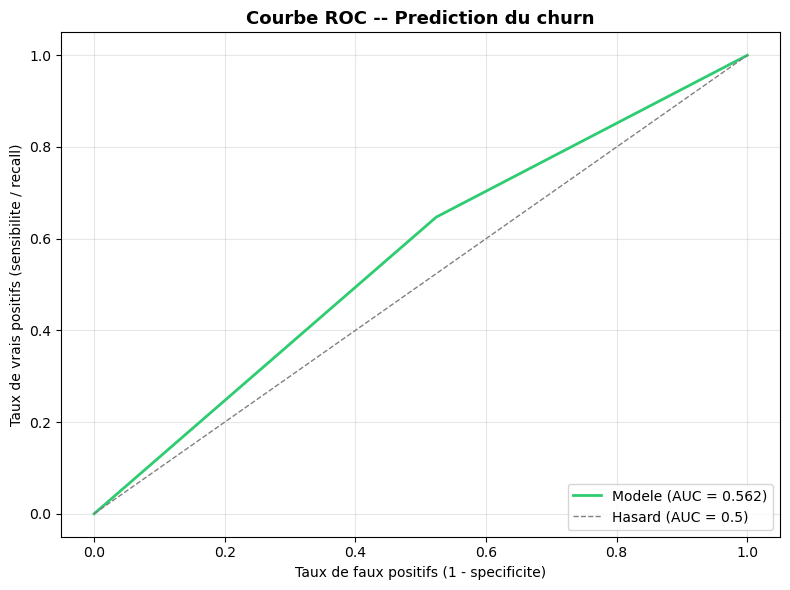

In [25]:

display(HTML("<h1 style='font-size:36px;text-align:center;'>OPTIMISATION/ ENTRAINEMENT / EVALUATION </h1>"))

#  HYPERPARAMETER TUNING (sur le pipeline complet, le meilleur trouve)
display(HTML("<h1 style='font-size:20px;color:blue;'>Hyperparameter Tuning</h1>"))

# La grille depend du modele contenu dans le nom de la meilleure combinaison (meilleur_nom)
if "RandomForest" in meilleur_nom:
    param_grid = {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [4, 6, 8, None],
        "selector__k": [8, 10, 15, 18, 20],
    }
elif "LogisticRegression" in meilleur_nom:
    param_grid = {
        "model__C": [0.01, 0.1, 1, 10],
        "selector__k": [8, 10, 15, 18, 20],
    }
else:  # XGBoost
    param_grid = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [2, 3, 4],
        "model__learning_rate": [0.01, 0.1, 0.3],
        "selector__k": [8, 10, 15, 18, 20],
    }

grid_search = GridSearchCV(
    best_pipeline, param_grid, cv=cv, scoring="f1", n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Meilleure combinaison de depart :", meilleur_nom)
print("Meilleurs hyperparametres :", grid_search.best_params_)
print("Meilleur score CV (F1) :", round(grid_search.best_score_, 4))

final_model = grid_search.best_estimator_

# voir les kbest colonnes 
noms_apres_preprocessing = final_model.named_steps["preprocessor"].get_feature_names_out()
selector = final_model.named_steps["selector"]
mask_selectionne = selector.get_support()
colonnes_retenues = noms_apres_preprocessing[mask_selectionne]
print(f"\n{mask_selectionne.sum()} colonnes retenues par SelectKBest sur {len(noms_apres_preprocessing)} :")
print(colonnes_retenues)




# ETAPE 13 : EVALUATION -- UNE SEULE FOIS SUR X_TEST
display(HTML("<h1 style='font-size:20px;color:blue;'>Evaluation finale sur X_test</h1>"))
final_model.fit(X_train, y_train)
y_pred= final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, y_proba)
print("\033[1m--- Avec le seuil par defaut (0.50) ---\033[0m")
print(classification_report(y_test, y_pred))
print("F1 test :", round(f1_score(y_test, y_pred), 4))


print("ROC AUC test (independant du seuil) :", round(roc_auc_score(y_test, y_proba), 4))


fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="#2ecc71", lw=2, label=f"Modele (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Hasard (AUC = 0.5)")
plt.xlabel("Taux de faux positifs (1 - specificite)")
plt.ylabel("Taux de vrais positifs (sensibilite / recall)")
plt.title("Courbe ROC -- Prediction du churn", fontsize=13, fontweight="bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




Background dataset has 800 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=800 when initializing the masker.


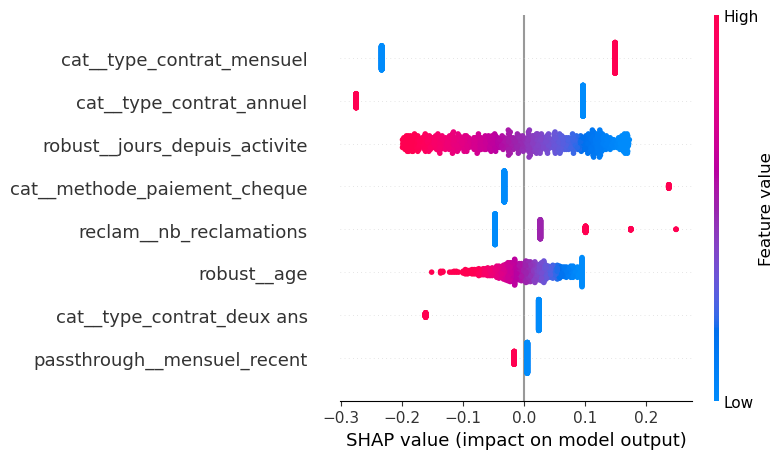

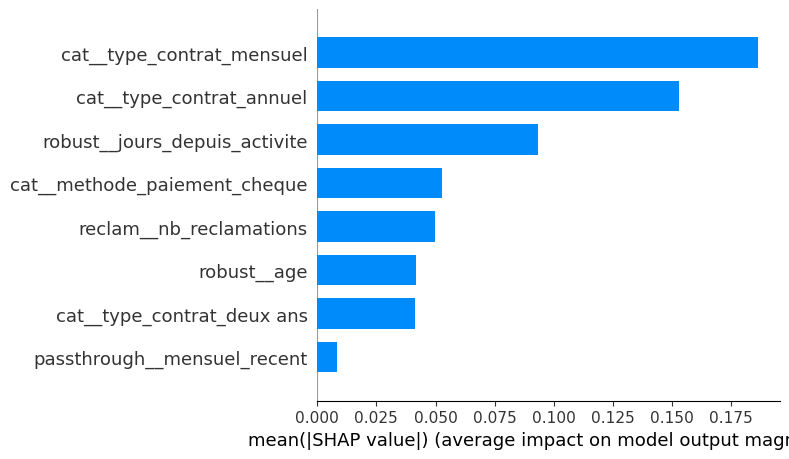

 DECISION: le summary plot SHAP donne, en plus du classement d'importance deja fourni par
SelectKBest, le SENS de l'effet de chaque variable (une valeur elevee pousse-t-elle vers le churn
ou vers la fidelite). C'est l'information la plus actionnable pour le metier : elle permet de dire
PAR EXEMPLE si un contrat mensuel ou un nombre eleve de reclamations augmente reellement le risque
de churn, et pas seulement de savoir que ces variables comptent dans le modele.


In [23]:

display(HTML("<h1 style='font-size:36px;text-align:center;'>INTERPRETABILITE -- SHAP</h1>"))

# On recupere les donnees telles que vues par le modele final :
# apres preprocessing (imputation + scaling + encodage) ET apres selection de variables
X_test_preprocessed = final_model.named_steps["preprocessor"].transform(X_test)
X_test_selected = final_model.named_steps["selector"].transform(X_test_preprocessed)

noms_apres_preprocessing_2 = final_model.named_steps["preprocessor"].get_feature_names_out()
mask_selectionne_2 = final_model.named_steps["selector"].get_support()
noms_features_finales = noms_apres_preprocessing_2[mask_selectionne_2]

# Conversion en DataFrame dense pour que shap puisse afficher les noms de colonnes
if hasattr(X_test_selected, "toarray"):
    X_test_selected = X_test_selected.toarray()
X_test_selected_df = pd.DataFrame(X_test_selected, columns=noms_features_finales, index=X_test.index)

modele_final_seul = final_model.named_steps["model"]

# Choix de l'explainer SHAP adapte au type de modele retenu
if "LogisticRegression" in meilleur_nom:
    explainer = shap.LinearExplainer(modele_final_seul, X_test_selected_df)
    shap_values = explainer(X_test_selected_df)
elif "RandomForest" in meilleur_nom or "XGBoost" in meilleur_nom:
    explainer = shap.TreeExplainer(modele_final_seul)
    shap_values = explainer(X_test_selected_df)
else:
    explainer = shap.Explainer(modele_final_seul, X_test_selected_df)
    shap_values = explainer(X_test_selected_df)

# Summary plot -- impact de chaque variable sur la prediction (direction + amplitude)
display(HTML("<h1 style='font-size:20px;color:blue;'>SHAP summary plot (impact et direction)</h1>"))
plt.figure()
shap.summary_plot(shap_values, X_test_selected_df, show=False)
plt.tight_layout()
plt.show()

# Bar plot -- importance moyenne absolue de chaque variable (classement global)
display(HTML("<h1 style='font-size:20px;color:blue;'>SHAP bar plot (importance globale)</h1>"))
plt.figure()
shap.summary_plot(shap_values, X_test_selected_df, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

print("\033[94m DECISION: le summary plot SHAP donne, en plus du classement d'importance deja fourni par\n"
      "SelectKBest, le SENS de l'effet de chaque variable (une valeur elevee pousse-t-elle vers le churn\n"
      "ou vers la fidelite). C'est l'information la plus actionnable pour le metier : elle permet de dire\n"
      "PAR EXEMPLE si un contrat mensuel ou un nombre eleve de reclamations augmente reellement le risque\n"
      "de churn, et pas seulement de savoir que ces variables comptent dans le modele.\033[0m")


In [24]:
# SAUVEGARDE DU MODELE FINAL (pipeline complet + seuil optimise, pret pour deploiement API)

display(HTML("<h1 style='font-size:20px;color:blue;'>Sauvegarde du modele final</h1>"))

joblib.dump( final_model, "modele_churn_final.pkl")
print("\033[92m RESULTAT: pipeline complet (preprocessing + selection + modele) ET seuil de decision optimise sauvegardes dans 'modele_churn_final.pkl'.\033[0m")
print(f"Modele retenu : {meilleur_nom}")
print(f"F1 en cross-validation (apres tuning ) : {round(grid_search.best_score_, 4)}")
print(f"F1 sur X_test  : {round(f1_score(y_test, y_pred), 4)}")

print("\033[94m Le F1-score obtenu est de 0.3657. Concernant la rigueur et la logique de la démarche\n "
      "(nettoyage, gestion des types, encodage, traitement des valeurs aberrantes), tout est correct. "
      "Cependant, la performance du modèle reste largement faible. Cela ne provient donc pas d'un manque\n "
      "de rigueur dans le pipeline, mais plutôt du bruit présent dans les données elles-mêmes. \033[0m")

print("""
\033[94m DECISION: le fichier modele_churn_final.pkl contient le pipeline complet 
-> pour l'utiliser sur de nouvelles donnees, il suffit de faire :

    objet = joblib.load("modele_churn_final.pkl")
    predictions = modele.predict(nouvelles_donnees)


sans avoir a refaire manuellement le pretraitement (sauf le nettoyage LEGER
initial : types, doublons, categories mal ecrites, qui restent hors pipeline
et doivent etre reappliques sur toute nouvelle donnee brute).\033[0m
""")


 RESULTAT: pipeline complet (preprocessing + selection + modele) ET seuil de decision optimise sauvegardes dans 'modele_churn_final.pkl'.
Modele retenu : LogisticRegression (class_weight)
F1 en cross-validation (apres tuning ) : 0.3737
F1 sur X_test  : 0.3607
 Le F1-score obtenu est de 0.3657. Concernant la rigueur et la logique de la démarche
 (nettoyage, gestion des types, encodage, traitement des valeurs aberrantes), tout est correct. Cependant, la performance du modèle reste largement faible. Cela ne provient donc pas d'un manque
 de rigueur dans le pipeline, mais plutôt du bruit présent dans les données elles-mêmes. 

 DECISION: le fichier modele_churn_final.pkl contient le pipeline complet 
-> pour l'utiliser sur de nouvelles donnees, il suffit de faire :

    objet = joblib.load("modele_churn_final.pkl")
    predictions = modele.predict(nouvelles_donnees)


sans avoir a refaire manuellement le pretraitement (sauf le nettoyage LEGER
initial : types, doublons, categories mal ecrit